# 📊 Proyecto Integrador — Bootcamp de Data Science
## E-commerce Transactions + Clickstream Dataset

**Tablas analizadas:** `customers.csv`, `sessions.csv`

## 0. Configuración del entorno

Importación de librerías y configuración de estilo para todas las visualizaciones del notebook.

In [1]:
import sys
from pathlib import Path

# Ruta raíz del proyecto
PROJECT_ROOT = Path.cwd().parent

# Agregar SRC al path
sys.path.append(str(PROJECT_ROOT / "SRC"))

from utils import (
    verificar_integridad_referencial,
    convertir_columnas_fecha,
    calcular_sets_eventos_sesion
)

In [2]:
# Librerías de manipulación de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para los gráficos del notebook
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


In [3]:
# Carga de los datasets del proyecto (una única vez, para todo el notebook)
DATA_DIR = PROJECT_ROOT / "Data" / "Raw"

customers = pd.read_csv(DATA_DIR / "customers.csv")
sessions = pd.read_csv(DATA_DIR / "sessions.csv")
events = pd.read_csv(DATA_DIR / "events.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv")

print("Datasets cargados correctamente.\n")
print(f"Customers:     {customers.shape}")
print(f"Sessions:      {sessions.shape}")
print(f"Events:        {events.shape}")
print(f"Orders:        {orders.shape}")
print(f"Order Items:   {order_items.shape}")
print(f"Products:      {products.shape}")
print(f"Reviews:       {reviews.shape}")

Datasets cargados correctamente.

Customers:     (20000, 7)
Sessions:      (120000, 6)
Events:        (760958, 10)
Orders:        (33580, 10)
Order Items:   (59163, 5)
Products:      (1197, 6)
Reviews:       (10780, 6)


---
## 1. Análisis exploratorio de las tablas

## 1.1 `customers.csv`

### Objetivo de la tabla
`customers.csv` es la **tabla maestra de clientes**. Contiene un registro por cada cliente único que se ha registrado en la plataforma de e-commerce, con sus atributos demográficos y de contacto. Es la tabla de referencia (dimensión) que permite identificar **quién es** cada cliente.


In [4]:
# Número de registros y columnas
n_rows, n_cols = customers.shape
print(f"Número de registros (clientes): {n_rows:,}")
print(f"Número de columnas: {n_cols}")
print(f"\nColumnas: {list(customers.columns)}")


Número de registros (clientes): 20,000
Número de columnas: 7

Columnas: ['customer_id', 'name', 'email', 'country', 'age', 'signup_date', 'marketing_opt_in']


In [5]:
# Tipo de dato de cada columna (según pandas)
customers.dtypes.to_frame(name='tipo_de_dato_pandas')


,tipo_de_dato_pandas
customer_id,int64
name,str
email,str
country,str
age,int64
signup_date,str
marketing_opt_in,bool


In [6]:
# Vista previa de los primeros registros
customers.head(5)


,customer_id,name,email,country,age,signup_date,marketing_opt_in
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,2020-09-04,True
1,2,Phillip Ramos,christinarubio@example.com,IN,26,2020-04-05,False
2,3,Dawn Fowler,jessica03@example.org,BR,21,2023-08-31,True
3,4,Mario Butler,paula27@example.org,FR,63,2022-06-30,True
4,5,Amber Brown,kevin85@example.net,BR,19,2022-07-22,True


### Diccionario de datos — `customers.csv`

| # | Columna | Tipo (pandas) | Tipo real de negocio | Descripción |
|---|---|---|---|---|
| 1 | `customer_id` | int64 | Identificador único | Llave primaria del cliente. No presenta duplicados (verificado abajo). |
| 2 | `name` | object (str) | Texto | Nombre completo del cliente (dato sintético/ficticio). |
| 3 | `email` | object (str) | Texto / contacto | Correo electrónico del cliente. Único por cliente (verificado abajo). |
| 4 | `country` | object (str) | Categórica (código ISO-2) | País de registro del cliente, codificado en 2 letras (ej. `US`, `IN`, `GB`). |
| 5 | `age` | int64 | Numérica discreta | Edad del cliente en años. |
| 6 | `signup_date` | object (str, se convierte a datetime) | Fecha | Fecha en la que el cliente se registró en la plataforma. |
| 7 | `marketing_opt_in` | bool | Booleana | Indica si el cliente aceptó recibir comunicaciones de marketing (`True`/`False`). |

**Nota:** estas son **todas** las columnas presentes en el archivo real. No existen columnas de género (`gender`), segmento, ciudad, dirección, ni ningún identificador de compra en esta tabla — si el modelo de negocio las requiere, deberán solicitarse en una fase posterior o confirmarse que no están disponibles en el dataset.


## 1.2 `sessions.csv`

### Objetivo de la tabla
`sessions.csv` es una **tabla de eventos de comportamiento (clickstream)**. Contiene un registro por cada **sesión de navegación** que un cliente realizó en el sitio web, con el momento, el dispositivo y el canal de origen. Es la tabla que permite entender **cómo y cuándo interactúan** los clientes con la plataforma. No es una tabla de transacciones: no contiene productos, montos ni indicadores de compra.


In [7]:
# Número de registros y columnas
n_rows_s, n_cols_s = sessions.shape
print(f"Número de registros (sesiones): {n_rows_s:,}")
print(f"Número de columnas: {n_cols_s}")
print(f"\nColumnas: {list(sessions.columns)}")


Número de registros (sesiones): 120,000
Número de columnas: 6

Columnas: ['session_id', 'customer_id', 'start_time', 'device', 'source', 'country']


In [8]:
# Tipo de dato de cada columna (según pandas)
sessions.dtypes.to_frame(name='tipo_de_dato_pandas')


,tipo_de_dato_pandas
session_id,int64
customer_id,int64
start_time,str
device,str
source,str
country,str


In [9]:
# Vista previa de los primeros registros
sessions.head(5)


,session_id,customer_id,start_time,device,source,country
0,1,12360,2021-12-27T00:01:36,mobile,email,DE
1,2,13917,2025-01-31T21:29:42,desktop,organic,PL
2,3,1022,2024-02-19T00:52:50,tablet,organic,FR
3,4,2882,2024-08-04T19:54:31,mobile,direct,GB
4,5,1286,2022-06-28T13:58:08,desktop,email,ES


### Diccionario de datos — `sessions.csv`

| # | Columna | Tipo (pandas) | Tipo real de negocio | Descripción |
|---|---|---|---|---|
| 1 | `session_id` | int64 | Identificador único | Llave primaria de la sesión. No presenta duplicados (verificado abajo). |
| 2 | `customer_id` | int64 | Llave foránea | Referencia al cliente (`customers.customer_id`) que originó la sesión. |
| 3 | `start_time` | object (str, se convierte a datetime) | Fecha y hora | Momento exacto (timestamp) de inicio de la sesión. |
| 4 | `device` | object (str) | Categórica | Tipo de dispositivo usado: `mobile`, `desktop` o `tablet`. |
| 5 | `source` | object (str) | Categórica | Canal de adquisición/origen de la sesión: `organic`, `direct`, `paid`, `social`, `email`, `referral`. |
| 6 | `country` | object (str) | Categórica (código ISO-2) | País desde el cual se originó la sesión. |

**Nota:** estas son **todas** las columnas presentes en el archivo real. No existen columnas de duración de sesión, páginas vistas, producto visitado, carrito de compra ni conversión. Por lo tanto, **no es posible calcular con estos datos**: tasa de conversión, ticket promedio, productos más vistos/comprados, ni ningún indicador monetario. Esto se reitera porque condiciona directamente el alcance de la Fase 2.


## 1.3 Calidad de datos

Se evalúan tres dimensiones de calidad para ambas tablas: **valores nulos**, **duplicados** e **inconsistencias** (formatos, rangos, tipos).


In [10]:
# --- VALORES NULOS ---
print("Valores nulos por columna - customers.csv")
print(customers.isnull().sum())
print("\nValores nulos por columna - sessions.csv")
print(sessions.isnull().sum())

print("\nPorcentaje de nulos - customers.csv (%)")
print((customers.isnull().mean()*100).round(2))
print("\nPorcentaje de nulos - sessions.csv (%)")
print((sessions.isnull().mean()*100).round(2))


Valores nulos por columna - customers.csv
customer_id         0
name                0
email               0
country             0
age                 0
signup_date         0
marketing_opt_in    0
dtype: int64

Valores nulos por columna - sessions.csv
session_id     0
customer_id    0
start_time     0
device         0
source         0
country        0
dtype: int64

Porcentaje de nulos - customers.csv (%)
customer_id         0.0
name                0.0
email               0.0
country             0.0
age                 0.0
signup_date         0.0
marketing_opt_in    0.0
dtype: float64

Porcentaje de nulos - sessions.csv (%)
session_id     0.0
customer_id    0.0
start_time     0.0
device         0.0
source         0.0
country        0.0
dtype: float64


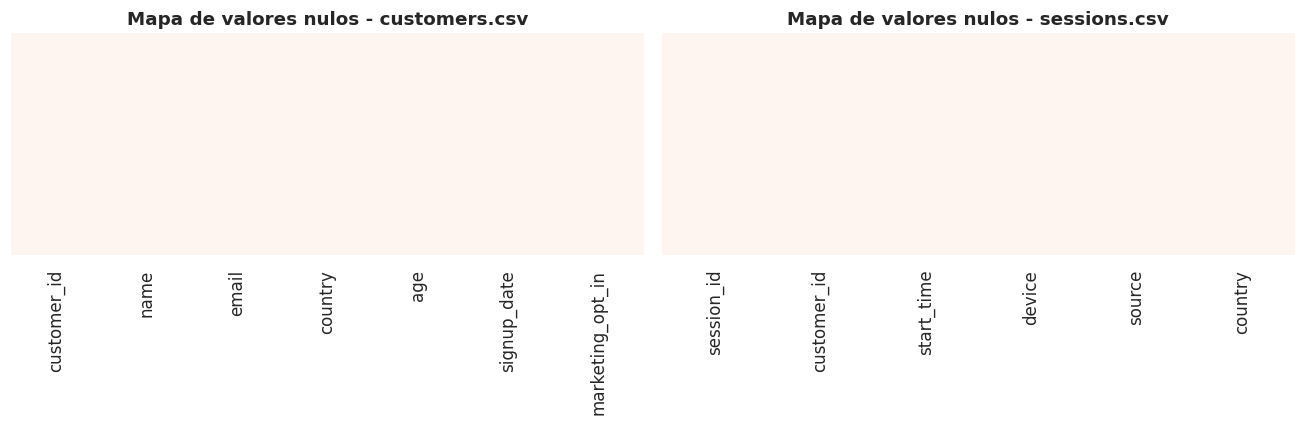

In [11]:
# Mapa de calor de valores nulos (heatmap) para ambas tablas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(customers.isnull(), cbar=False, cmap='Reds', yticklabels=False, ax=axes[0])
axes[0].set_title('Mapa de valores nulos - customers.csv')
sns.heatmap(sessions.isnull(), cbar=False, cmap='Reds', yticklabels=False, ax=axes[1])
axes[1].set_title('Mapa de valores nulos - sessions.csv')
plt.tight_layout()
plt.show()


**💡 Análisis técnico:** las franjas completamente vacías (sin color rojo) confirman que ninguna columna de ninguna de las dos tablas presenta valores nulos.

**💡 Insight de negocio:** el dataset tiene una calidad excepcionalmente alta en cuanto a completitud (0% de nulos en las 13 columnas combinadas). Esto reduce significativamente el esfuerzo de limpieza y permite confiar en los indicadores agregados (edades, países, fechas) sin necesidad de imputación.


In [12]:
# --- DUPLICADOS ---
print("customers.csv")
print(" - Filas totalmente duplicadas:", customers.duplicated().sum())
print(" - customer_id duplicados:", customers['customer_id'].duplicated().sum())
print(" - email duplicados (case-insensitive):", customers['email'].str.lower().duplicated().sum())
print(" - name duplicados (nombre y apellido repetido):", customers['name'].duplicated().sum())

print("\nsessions.csv")
print(" - Filas totalmente duplicadas:", sessions.duplicated().sum())
print(" - session_id duplicados:", sessions['session_id'].duplicated().sum())


customers.csv
 - Filas totalmente duplicadas: 0
 - customer_id duplicados: 0
 - email duplicados (case-insensitive): 0
 - name duplicados (nombre y apellido repetido): 2085

sessions.csv
 - Filas totalmente duplicadas: 0
 - session_id duplicados: 0


**💡 Análisis técnico:** no existen filas duplicadas ni duplicados en las llaves primarias (`customer_id`, `session_id`, `email`). Sí se observan **2,085 nombres repetidos** en `name`, lo cual es esperable estadísticamente (nombres comunes como "John Smith" pueden repetirse entre miles de personas reales) y **no representa un problema de calidad**, ya que la unicidad real del cliente está garantizada por `customer_id` y `email`.

**💡 Insight de negocio:** la ausencia de duplicados en las llaves primarias garantiza que los conteos de clientes y sesiones que se presentan en este informe son fiables y no están inflados por registros repetidos.


In [13]:
# --- INCONSISTENCIAS: rangos y formatos ---

# Rango de edad (¿hay edades negativas o imposibles, ej. > 100?)
print("Edad mínima:", customers['age'].min(), "| Edad máxima:", customers['age'].max())
print("Edades negativas:", (customers['age'] < 0).sum())
print("Edades > 100 años:", (customers['age'] > 100).sum())

# Consistencia del código de país (longitud de 2 caracteres en ambas tablas)
print("\nLongitud de 'country' distinta a 2 caracteres (customers):", (customers['country'].str.len() != 2).sum())
print("Longitud de 'country' distinta a 2 caracteres (sessions):", (sessions['country'].str.len() != 2).sum())

# Fechas fuera de rango logico (fechas futuras respecto al máximo del propio dataset)
customers = convertir_columnas_fecha(customers, ['signup_date'])
sessions = convertir_columnas_fecha(sessions, ['start_time'])
print("\nRango de signup_date:", customers['signup_date'].min().date(), "->", customers['signup_date'].max().date())
print("Rango de start_time :", sessions['start_time'].min(), "->", sessions['start_time'].max())

# ¿Todos los valores de device y source son categorías esperadas (sin typos)?
print("\nValores únicos de 'device':", sorted(sessions['device'].unique()))
print("Valores únicos de 'source':", sorted(sessions['source'].unique()))
print("Valores únicos de 'marketing_opt_in':", sorted(customers['marketing_opt_in'].unique()))


Edad mínima: 18 | Edad máxima: 75
Edades negativas: 0
Edades > 100 años: 0

Longitud de 'country' distinta a 2 caracteres (customers): 0
Longitud de 'country' distinta a 2 caracteres (sessions): 0

Rango de signup_date: 2020-01-01 -> 2025-10-31
Rango de start_time : 2020-01-01 00:06:58 -> 2025-10-31 23:34:11

Valores únicos de 'device': ['desktop', 'mobile', 'tablet']
Valores únicos de 'source': ['direct', 'email', 'organic', 'paid', 'referral', 'social']
Valores únicos de 'marketing_opt_in': [np.False_, np.True_]


**💡 Análisis técnico:** no se detectan inconsistencias de formato ni de rango:
- Las edades están acotadas entre **18 y 75 años** (rango lógico y coherente con una plataforma de e-commerce sin menores de edad).
- Los códigos de país tienen longitud homogénea de 2 caracteres en ambas tablas (17 países únicos en ambos casos, ver detalle en la Fase 2).
- Las fechas de registro y de sesión están dentro de un rango temporal coherente (2020-01-01 a 2025-10-31), sin fechas futuras ni corruptas.
- Las variables categóricas (`device`, `source`, `marketing_opt_in`) tienen exactamente las categorías esperadas, sin errores de tipeo ni variantes de mayúsculas/minúsculas.

**💡 Insight de negocio:** este es un dataset limpio, muy probablemente ya curado/sintético para fines educativos. Esto es positivo para el ejercicio del bootcamp, pero en un entorno productivo real se recomienda no asumir automáticamente este nivel de calidad y mantener controles de validación en la ingesta de datos.


## 1.4 Relación entre `customers` y `sessions`

La relación entre ambas tablas es de tipo **uno a muchos (1:N)**: un cliente (`customers.customer_id`) puede tener **cero, una o varias** sesiones registradas en `sessions.customer_id`. La llave de unión es `customer_id`.


In [14]:
# Integridad referencial: ¿todo customer_id de sessions existe en customers?
n_huerfanas = verificar_integridad_referencial(sessions, "customer_id", customers, "customer_id")
print("Sesiones cuyo customer_id NO existe en customers.csv (huérfanas):", n_huerfanas)

# Clientes sin ninguna sesión registrada (relación inversa, no aplica a verificar_integridad_referencial)
clientes_con_sesion = sessions['customer_id'].unique()
clientes_sin_sesion = customers[~customers['customer_id'].isin(clientes_con_sesion)]
print(f"Clientes registrados SIN ninguna sesión: {len(clientes_sin_sesion):,} de {len(customers):,} ({len(clientes_sin_sesion)/len(customers)*100:.2f}%)")

# Clientes únicos que sí generaron al menos una sesión
print(f"Clientes con al menos 1 sesión: {sessions['customer_id'].nunique():,}")

Sesiones cuyo customer_id NO existe en customers.csv (huérfanas): 0
Clientes registrados SIN ninguna sesión: 55 de 20,000 (0.27%)
Clientes con al menos 1 sesión: 19,945


**💡 Análisis técnico:** la integridad referencial es del **100%**: cada sesión pertenece a un cliente que existe en `customers.csv` (0 sesiones huérfanas). Sin embargo, **55 clientes (0.28%)** están registrados pero **nunca generaron una sesión**.

**💡 Insight de negocio:** ese pequeño grupo de 55 clientes representa registros que se dieron de alta pero jamás volvieron a interactuar con la plataforma — un indicio temprano de **abandono post-registro** que amerita seguimiento (por ejemplo, campañas de reactivación) aunque su tamaño no es estadísticamente relevante sobre el total de la base.


## 1.5 Preguntas de negocio que permite responder cada tabla

**Con `customers.csv` se puede responder:**
- ¿Cuál es el perfil demográfico de la base de clientes (edad, país)?
- ¿Cómo ha evolucionado la adquisición de nuevos clientes en el tiempo (por `signup_date`)?
- ¿Qué proporción de clientes acepta comunicaciones de marketing (`marketing_opt_in`)?
- ¿En qué países está concentrada la base de clientes?
- ¿Qué tan antigua o reciente es la base de clientes (antigüedad desde el registro)?

**Con `sessions.csv` se puede responder:**
- ¿Con qué frecuencia interactúan los clientes con la plataforma (sesiones por cliente)?
- ¿Desde qué dispositivos navegan los clientes (mobile / desktop / tablet)?
- ¿Por qué canal llegan las sesiones (orgánico, pago, email, social, referido, directo)?
- ¿Cómo se distribuye la actividad de navegación en el tiempo?
- ¿Qué clientes son los más activos en términos de número de sesiones?

**Lo que NINGUNA de las dos tablas permite responder (limitación explícita):**
- ¿Qué compran los clientes, cuánto gastan o con qué frecuencia compran? (no existe tabla de transacciones/pedidos)
- ¿Cuál es la tasa de conversión de sesión a compra?
- ¿Cuáles son los productos o categorías más vendidos?
- ¿Cuál es el valor de vida del cliente (LTV) o el ticket promedio?

## 1.6 Conclusiones de la sección

1. **Calidad de datos alta:** 0% de valores nulos, 0 duplicados en llaves primarias e integridad referencial del 100% entre `sessions` y `customers`. La base es confiable para el análisis exploratorio.
2. **Relación 1:N clara:** cada cliente puede generar múltiples sesiones; en promedio cada cliente activo genera un número de sesiones que se cuantifica en la Fase 2.
3. **Cobertura geográfica amplia:** ambas tablas comparten el mismo universo de 17 países, lo que permite cruces geográficos consistentes.
4. **Limitación estructural relevante:** al no existir una tabla de transacciones, el análisis de "quién compra" en la Fase 2 se aborda como **"quién es el cliente y cómo navega"**, no como comportamiento de compra real. Esta limitación debe comunicarse explícitamente a las siguientes fases del proyecto integrador (por ejemplo, si otro compañero recibe una tabla de `transactions.csv`, ese análisis sí podrá hablar de compras en sentido estricto).


---
## 2.1 ¿Quién compra?

Como se documentó en la Fase 1, ninguna de las dos tablas disponibles (`customers.csv`, `sessions.csv`) contiene información de transacciones. Por lo tanto, esta pregunta se responde caracterizando **quién es el cliente** (demografía, geografía, antigüedad) y **cómo se comporta en el sitio** (frecuencia de sesiones), que es la mejor aproximación posible a "quién compra" con los datos entregados.


In [15]:
# Dataset consolidado: sesiones por cliente, unido a los atributos del cliente
sesiones_por_cliente = sessions.groupby('customer_id').size().rename('n_sessions')

df = customers.merge(sesiones_por_cliente, left_on='customer_id', right_index=True, how='left')
df['n_sessions'] = df['n_sessions'].fillna(0).astype(int)

print(f"Dataset consolidado: {df.shape[0]:,} clientes x {df.shape[1]} columnas")
df.head()


Dataset consolidado: 20,000 clientes x 8 columnas


,customer_id,name,email,country,age,signup_date,marketing_opt_in,n_sessions
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,2020-09-04,True,5
1,2,Phillip Ramos,christinarubio@example.com,IN,26,2020-04-05,False,3
2,3,Dawn Fowler,jessica03@example.org,BR,21,2023-08-31,True,5
3,4,Mario Butler,paula27@example.org,FR,63,2022-06-30,True,9
4,5,Amber Brown,kevin85@example.net,BR,19,2022-07-22,True,9


### 2.1.1 Edad de los clientes

### Explicación técnica
Se analiza la distribución de la variable `age` mediante estadísticas descriptivas, histograma y boxplot para identificar tendencia central, dispersión y posibles valores atípicos.


In [16]:
# Estadísticas descriptivas de la edad
customers['age'].describe().round(2)


count    20000.00
mean        46.49
std         16.77
min         18.00
25%         32.00
50%         46.50
75%         61.00
max         75.00
Name: age, dtype: float64

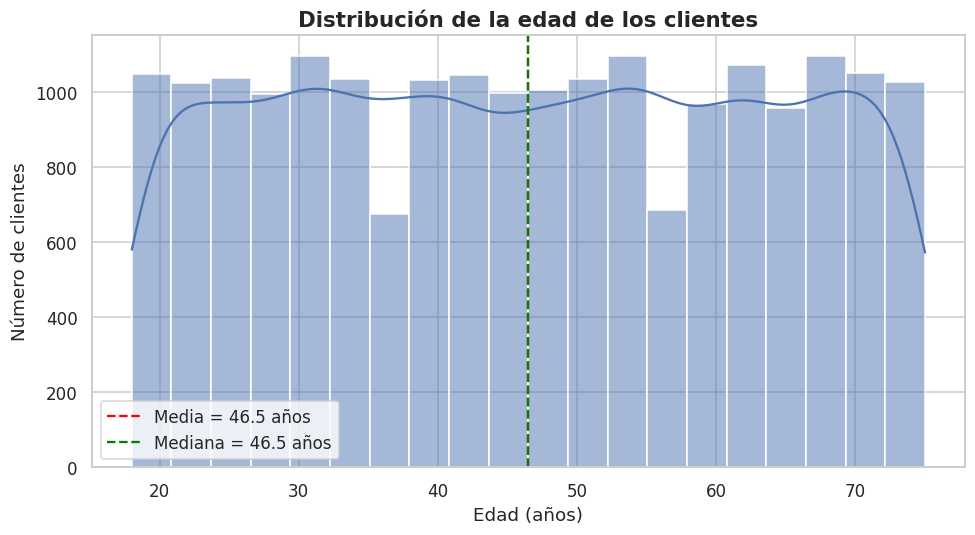

In [17]:
# Histograma de la edad de los clientes
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(customers['age'], bins=20, kde=True, color='#4C72B0', ax=ax)
ax.set_title('Distribución de la edad de los clientes', fontsize=14)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Número de clientes')
ax.axvline(customers['age'].mean(), color='red', linestyle='--',
           label=f"Media = {customers['age'].mean():.1f} años")
ax.axvline(customers['age'].median(), color='green', linestyle='--',
           label=f"Mediana = {customers['age'].median():.1f} años")
ax.legend()
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** la distribución de edades es prácticamente **uniforme entre los 18 y los 75 años**, sin un pico dominante en ningún tramo etario. La media (46.5 años) y la mediana (46.5 años) son casi idénticas, lo que confirma una distribución simétrica, sin sesgo hacia clientes jóvenes ni mayores.

**💡 Conclusión:** el negocio **no tiene un cliente "típico" por edad**; la base de clientes es transversal a todas las generaciones (Gen Z, Millennials, Gen X y Baby Boomers están representados de forma similar). Esto implica que las estrategias de marketing y comunicación **no deberían estar centradas en un único segmento etario**, sino diseñarse de forma segmentada por grupo de edad.


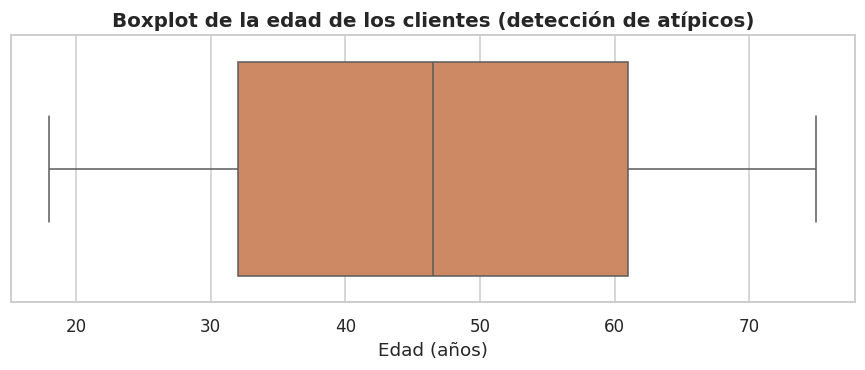

Q1 = 32.0, Q3 = 61.0, IQR = 29.0
Límite inferior aceptable: -11.5 | Límite superior aceptable: 104.5
Número de clientes con edad atípica (outliers): 0


In [18]:
# Boxplot de la edad + detección de atípicos mediante el método IQR
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.boxplot(x=customers['age'], color='#DD8452', ax=ax)
ax.set_title('Boxplot de la edad de los clientes (detección de atípicos)', fontsize=13)
ax.set_xlabel('Edad (años)')
plt.tight_layout()
plt.show()

# Cálculo formal de atípicos con el método del Rango Intercuartílico (IQR)
Q1 = customers['age'].quantile(0.25)
Q3 = customers['age'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
atipicos = customers[(customers['age'] < limite_inferior) | (customers['age'] > limite_superior)]

print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Límite inferior aceptable: {limite_inferior} | Límite superior aceptable: {limite_superior}")
print(f"Número de clientes con edad atípica (outliers): {len(atipicos)}")


**💡 Análisis técnico:** el boxplot no muestra ningún punto fuera de los bigotes y el cálculo formal por IQR confirma **0 valores atípicos** en la edad. El rango completo (18-75 años) está contenido dentro de los límites estadísticamente esperados.

**💡 Conclusión:** no hay señales de errores de captura en la edad (por ejemplo, edades de 0 o de 150 años que suelen aparecer en datos reales mal validados). La variable es confiable para segmentación etaria sin necesidad de tratamiento adicional de outliers.


age_group
18-24    2414
25-34    3498
35-44    3400
45-54    3445
55-64    3451
65-75    3792
Name: count, dtype: int64

Participación (%):
age_group
18-24    12.07
25-34    17.49
35-44    17.00
45-54    17.22
55-64    17.26
65-75    18.96
Name: count, dtype: float64


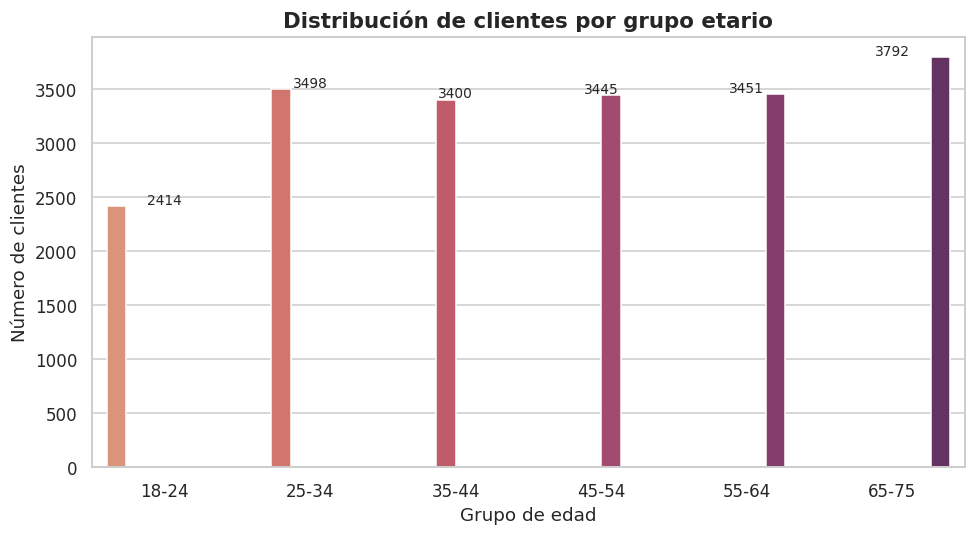

In [19]:
# Distribución de clientes por grupo etario (segmentación de negocio)
bins = [18, 25, 35, 45, 55, 65, 76]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-75']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, include_lowest=True, right=False)

grupo_edad = customers['age_group'].value_counts().sort_index()
print(grupo_edad)
print("\nParticipación (%):")
print((grupo_edad / grupo_edad.sum() * 100).round(2))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=grupo_edad.index, y=grupo_edad.values, hue=grupo_edad.index, palette='flare', legend=False, ax=ax)
ax.set_title('Distribución de clientes por grupo etario', fontsize=14)
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Número de clientes')
for i, v in enumerate(grupo_edad.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** todos los grupos etarios tienen una participación similar, entre el 12% (18-24 años) y el 17.5% (25-34, 35-44, 45-54 y 55-64 años cada uno). El grupo 18-24 es levemente menor porque el rango de edad de esa categoría es más corto (7 años vs. 10 años de los demás grupos).

**💡 Conclusión:** confirma que **no existe un segmento etario dominante**. Cualquier estrategia de personalización de producto o comunicación debe contemplar los seis grupos con un peso comparable, evitando asumir que la base es "joven" o "mayor" por defecto.


### 2.1.2 País

### Explicación técnica
Se analiza la variable categórica `country` de `customers.csv` (código ISO-2), contando la frecuencia absoluta y relativa de clientes por país.


In [20]:
# Distribución de clientes por país
paises = customers['country'].value_counts()
print(f"Número de países únicos: {customers['country'].nunique()}")
print("\nDistribución absoluta y porcentual:")
tabla_paises = pd.DataFrame({
    'n_clientes': paises,
    'pct': (paises / paises.sum() * 100).round(2)
})
tabla_paises


Número de países únicos: 17

Distribución absoluta y porcentual:


,n_clientes,pct
country,,
US,3648,18.24
IN,1589,7.94
GB,1585,7.92
BR,1421,7.10
DE,1397,6.98
FR,1325,6.62
MX,1206,6.03
AU,1045,5.22
CA,1015,5.08


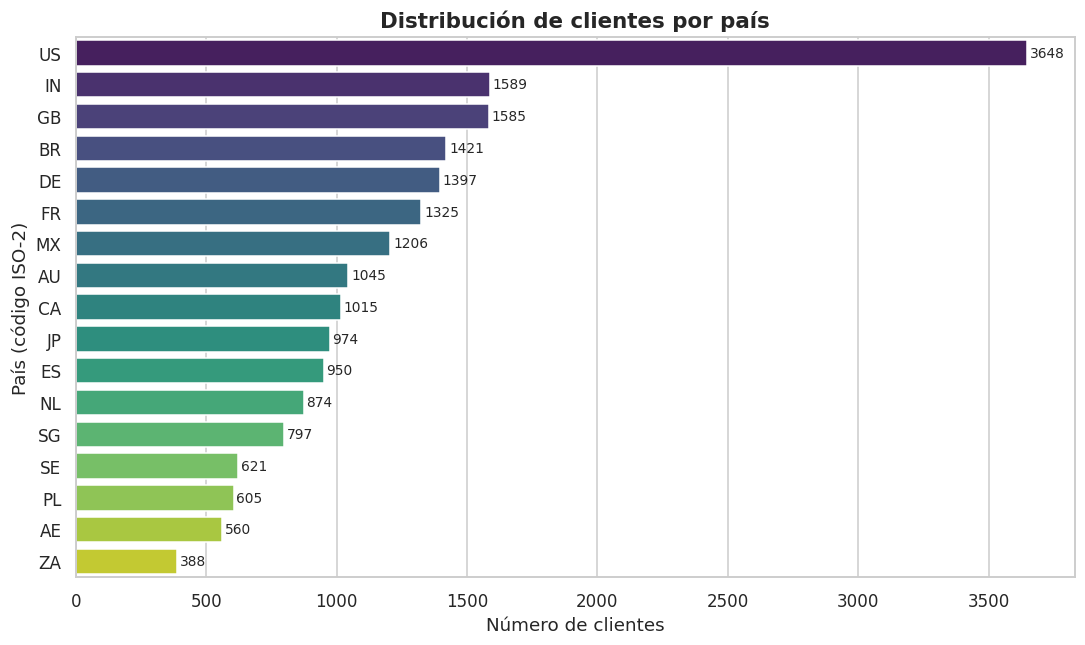

In [21]:
# Gráfico de barras: clientes por país
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=paises.values, y=paises.index, hue=paises.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Distribución de clientes por país', fontsize=14)
ax.set_xlabel('Número de clientes')
ax.set_ylabel('País (código ISO-2)')
for i, v in enumerate(paises.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** Estados Unidos (`US`) es, por amplio margen, el país con más clientes (3,648, ~18.2% del total), seguido de India (`IN`, 1,589), Reino Unido (`GB`, 1,585), Brasil (`BR`, 1,421) y Alemania (`DE`, 1,397). En el otro extremo, Sudáfrica (`ZA`, 388) es el mercado más pequeño de los 17 países presentes.

**💡 Conclusión:** el negocio tiene una **huella verdaderamente global** (17 países en 5 continentes), pero con una **concentración moderada en Estados Unidos**, que por sí solo representa cerca de 1 de cada 5.5 clientes. Esto sugiere priorizar recursos de soporte, logística y marketing en EE.UU., India, Reino Unido, Brasil y Alemania (que en conjunto concentran cerca del 45% de la base), sin descuidar la diversificación geográfica que reduce el riesgo de dependencia de un solo mercado.


### 2.1.3 Género

### Explicación técnica y limitación de datos
Se buscó explícitamente una columna de género (`gender`, `sex` o similar) en ambos archivos.


In [22]:
# Verificación explícita de existencia de columna de género
print("¿Existe columna de género en customers.csv?:", any('gender' in c.lower() or c.lower()=='sex' for c in customers.columns))
print("¿Existe columna de género en sessions.csv?:", any('gender' in c.lower() or c.lower()=='sex' for c in sessions.columns))
print("\nColumnas reales de customers.csv:", list(customers.columns))
print("Columnas reales de sessions.csv:", list(sessions.columns))


¿Existe columna de género en customers.csv?: False
¿Existe columna de género en sessions.csv?: False

Columnas reales de customers.csv: ['customer_id', 'name', 'email', 'country', 'age', 'signup_date', 'marketing_opt_in', 'age_group']
Columnas reales de sessions.csv: ['session_id', 'customer_id', 'start_time', 'device', 'source', 'country']


**Resultado:** la columna de género **no existe** en ninguna de las dos tablas entregadas. Siguiendo la instrucción explícita del proyecto de no inventar columnas, **este análisis se omite por completo** y no se realiza ningún supuesto ni imputación de género.

**💡 Conclusión:** si la segmentación por género es un requisito de negocio, debe solicitarse formalmente que se incorpore esa variable en una futura versión del dataset o en la tabla de clientes.


### 2.1.4 Clientes nuevos

### Explicación técnica
Se analiza `signup_date` para observar la evolución temporal de la adquisición de clientes. Como criterio operativo, se define **"cliente nuevo"** como aquel cuyo registro ocurrió dentro de los **90 días previos a la fecha más reciente presente en el dataset** (2025-10-31, que se usa como fecha de referencia porque es la última fecha real observada en los datos, no la fecha actual del calendario).


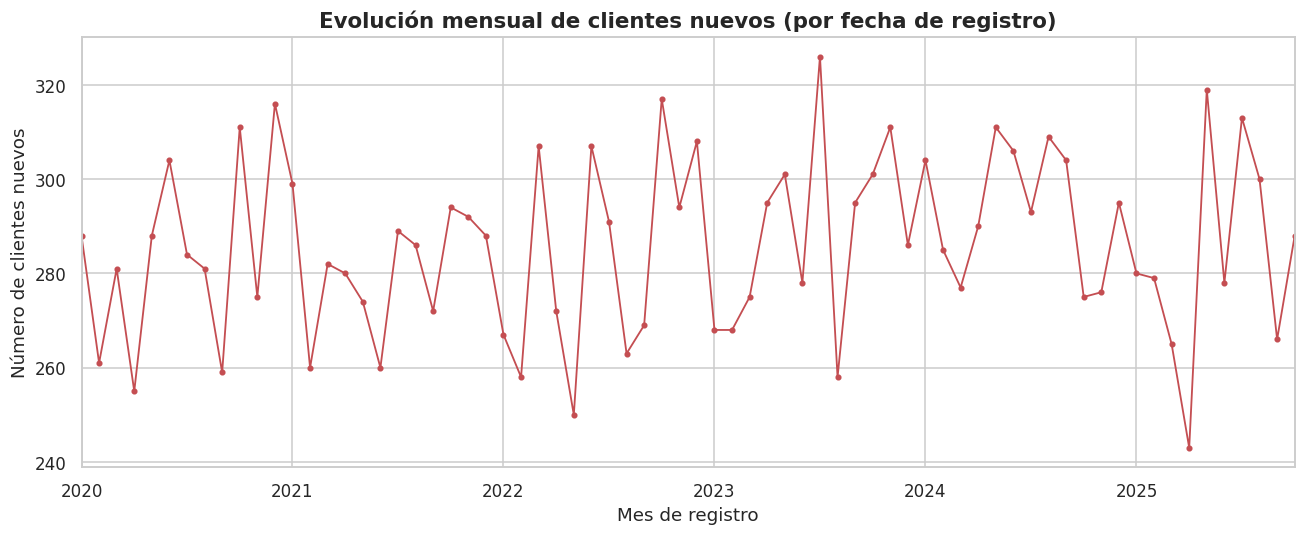

Altas de clientes por año:
signup_date
2020    3403
2021    3376
2022    3403
2023    3462
2024    3525
2025    2831
Name: count, dtype: int64


In [23]:
# Evolución mensual de altas de clientes (signup_date ya es datetime desde la sección 1.3)
altas_mensuales = customers.set_index('signup_date').resample('ME').size()

fig, ax = plt.subplots(figsize=(12, 5))
altas_mensuales.plot(ax=ax, color='#C44E52', marker='o', markersize=3, linewidth=1.2)
ax.set_title('Evolución mensual de clientes nuevos (por fecha de registro)', fontsize=14)
ax.set_xlabel('Mes de registro')
ax.set_ylabel('Número de clientes nuevos')
plt.tight_layout()
plt.show()

print("Altas de clientes por año:")
print(customers['signup_date'].dt.year.value_counts().sort_index())


**💡 Insight de negocio:** las altas mensuales se mantienen **relativamente estables** a lo largo de todo el periodo observado (2020-2025), sin una tendencia de crecimiento explosivo ni caídas abruptas. El año 2025 muestra un total menor (2,831) pero esto es un efecto de **corte de datos incompleto** (el año 2025 solo llega hasta octubre en el dataset), no una caída real de adquisición.

**💡 Conclusión:** la adquisición de clientes ha sido **constante en el tiempo**, lo cual sugiere un canal de captación maduro y predecible, pero también indica que **no ha habido una aceleración notable del crecimiento** en los últimos años — una oportunidad para evaluar nuevas inversiones en adquisición si el objetivo del negocio es escalar la base de clientes.


In [24]:
# Definición operativa de "cliente nuevo": registrado en los últimos 90 días
# respecto a la fecha máxima observada en el propio dataset (fecha de referencia del corte de datos)
fecha_referencia = max(customers['signup_date'].max(), sessions['start_time'].max())
customers['dias_desde_registro'] = (fecha_referencia - customers['signup_date']).dt.days

clientes_nuevos = customers[customers['dias_desde_registro'] <= 90]
print(f"Fecha de referencia (máxima fecha observada en el dataset): {fecha_referencia.date()}")
print(f"Clientes nuevos (registrados en los últimos 90 días respecto al corte): {len(clientes_nuevos):,} "
      f"({len(clientes_nuevos)/len(customers)*100:.2f}% del total)")


Fecha de referencia (máxima fecha observada en el dataset): 2025-10-31
Clientes nuevos (registrados en los últimos 90 días respecto al corte): 840 (4.20% del total)


**💡 Conclusión:** solo el **4.2% de la base (840 clientes)** se registró en los últimos 90 días del periodo observado. Esto es coherente con una base de clientes madura y estable, más que con una fase de crecimiento acelerado.


### 2.1.5 Clientes frecuentes

### Explicación técnica
No existiendo datos de compra, la "frecuencia" se aproxima mediante el **número de sesiones registradas por cliente** en `sessions.csv`. Se define como **"cliente frecuente"** aquel cuyo número de sesiones está en el **percentil 75 o superior** de la distribución (es decir, el 25% de clientes más activos).


In [25]:
# Número de sesiones por cliente
sesiones_por_cliente = sessions.groupby('customer_id').size()

p75 = sesiones_por_cliente.quantile(0.75)
clientes_frecuentes = sesiones_por_cliente[sesiones_por_cliente >= p75]

print(f"Percentil 75 de sesiones por cliente: {p75:.0f} sesiones")
print(f"Clientes frecuentes (>= {p75:.0f} sesiones): {len(clientes_frecuentes):,} "
      f"({len(clientes_frecuentes)/customers.shape[0]*100:.2f}% del total de clientes registrados)")
print(f"\nEstadísticas de sesiones para clientes frecuentes:")
print(clientes_frecuentes.describe().round(2))


Percentil 75 de sesiones por cliente: 8 sesiones
Clientes frecuentes (>= 8 sesiones): 5,133 (25.66% del total de clientes registrados)

Estadísticas de sesiones para clientes frecuentes:
count    5133.00
mean        9.24
std         1.47
min         8.00
25%         8.00
50%         9.00
75%        10.00
max        17.00
dtype: float64


**💡 Insight de negocio:** un **25.7% de la base de clientes** (5,133 clientes) concentra la mayor actividad de navegación, con **8 o más sesiones registradas** cada uno.

**💡 Conclusión:** este grupo de clientes altamente activos es el **candidato natural para programas de fidelización, upsell y comunicación prioritaria**, dado su nivel de interacción recurrente con la plataforma. Sin datos de compra no puede confirmarse si mayor navegación se traduce en mayor gasto, pero es la señal de "engagement" más fuerte disponible en este dataset.


### 2.1.6 Número de sesiones por cliente

### Explicación técnica
Se analiza la distribución completa de `n_sessions` (sesiones por cliente) con estadísticas descriptivas, histograma y boxplot.


In [26]:
# Estadísticas descriptivas de sesiones por cliente (incluye los 55 clientes con 0 sesiones)
df['n_sessions'].describe().round(2)


count    20000.00
mean         6.00
std          2.47
min          0.00
25%          4.00
50%          6.00
75%          8.00
max         17.00
Name: n_sessions, dtype: float64

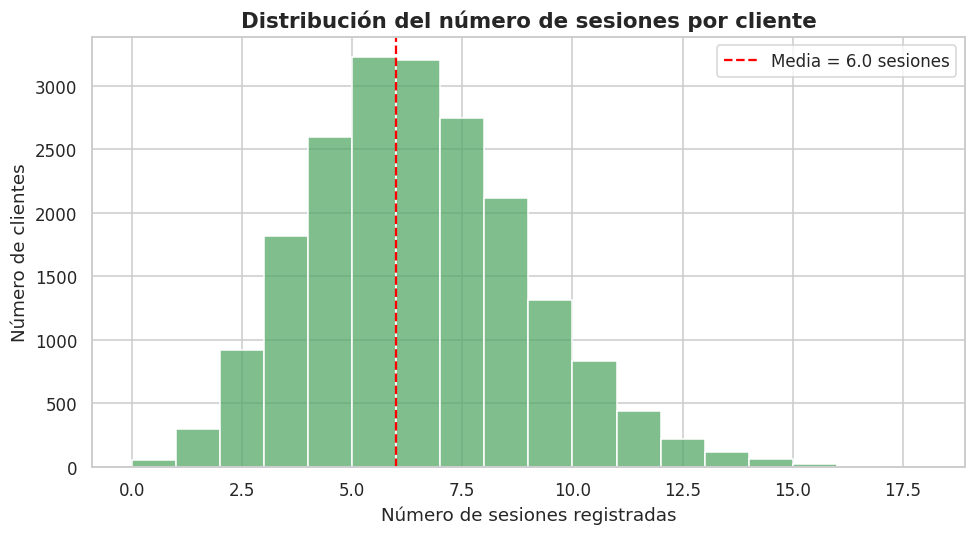

In [27]:
# Histograma del número de sesiones por cliente
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['n_sessions'], bins=range(0, 19), color='#55A868', ax=ax)
ax.set_title('Distribución del número de sesiones por cliente', fontsize=14)
ax.set_xlabel('Número de sesiones registradas')
ax.set_ylabel('Número de clientes')
ax.axvline(df['n_sessions'].mean(), color='red', linestyle='--',
           label=f"Media = {df['n_sessions'].mean():.1f} sesiones")
ax.legend()
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** la distribución es aproximadamente simétrica y con forma de campana centrada entre 4 y 8 sesiones por cliente, con una media de **6.0 sesiones**. No hay un grupo masivo de clientes con una sola sesión (comportamiento "probé una vez y me fui"), lo que es una señal saludable de retención.

**💡 Conclusión:** el cliente promedio de la plataforma **regresa varias veces**, no es un visitante de una sola vez. Esto sugiere una base de clientes relativamente comprometida con el sitio, aunque —de nuevo— sin datos de compra no se puede confirmar si ese regreso se traduce en ventas repetidas.


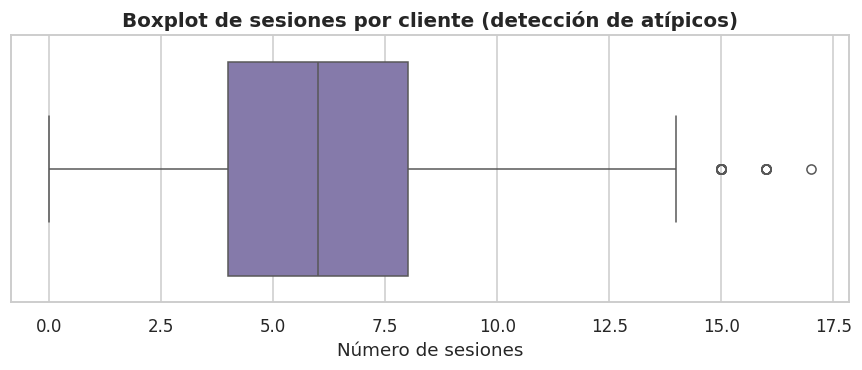

Q1=4.0, Q3=8.0, IQR=4.0
Límite inferior: -2.0 | Límite superior: 14.0
Clientes con número de sesiones atípico: 33
Máximo de sesiones registrado por un solo cliente: 17


In [28]:
# Boxplot de sesiones por cliente + atípicos por IQR
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.boxplot(x=df['n_sessions'], color='#8172B2', ax=ax)
ax.set_title('Boxplot de sesiones por cliente (detección de atípicos)', fontsize=13)
ax.set_xlabel('Número de sesiones')
plt.tight_layout()
plt.show()

Q1_s = df['n_sessions'].quantile(0.25)
Q3_s = df['n_sessions'].quantile(0.75)
IQR_s = Q3_s - Q1_s
lim_inf_s = Q1_s - 1.5 * IQR_s
lim_sup_s = Q3_s + 1.5 * IQR_s
atipicos_sesiones = df[(df['n_sessions'] < lim_inf_s) | (df['n_sessions'] > lim_sup_s)]

print(f"Q1={Q1_s}, Q3={Q3_s}, IQR={IQR_s}")
print(f"Límite inferior: {lim_inf_s} | Límite superior: {lim_sup_s}")
print(f"Clientes con número de sesiones atípico: {len(atipicos_sesiones)}")
print(f"Máximo de sesiones registrado por un solo cliente: {df['n_sessions'].max()}")


**💡 Análisis técnico:** no se detectan atípicos superiores relevantes por el método IQR (el límite superior calculado, ~14, es cercano al máximo real observado de 17 sesiones). El boxplot muestra que la mayoría de la actividad se concentra entre 4 y 8 sesiones, sin clientes con una cantidad desproporcionada de visitas que distorsione el análisis.

**💡 Conclusión:** no hay indicios de tráfico anómalo (por ejemplo, bots o errores de registro que generarían cientos de sesiones para un mismo cliente). Los datos de comportamiento son confiables para segmentar por nivel de actividad.


### 2.1.7 Distribución de clientes (vistas complementarias)

Se complementa el perfil del cliente con dos variables adicionales disponibles en `customers.csv`: `marketing_opt_in`, y con las variables de comportamiento de `sessions.csv`: `device` y `source`.


marketing_opt_in
True     11110
False     8890
Name: count, dtype: int64
marketing_opt_in
True     55.55
False    44.45
Name: count, dtype: float64


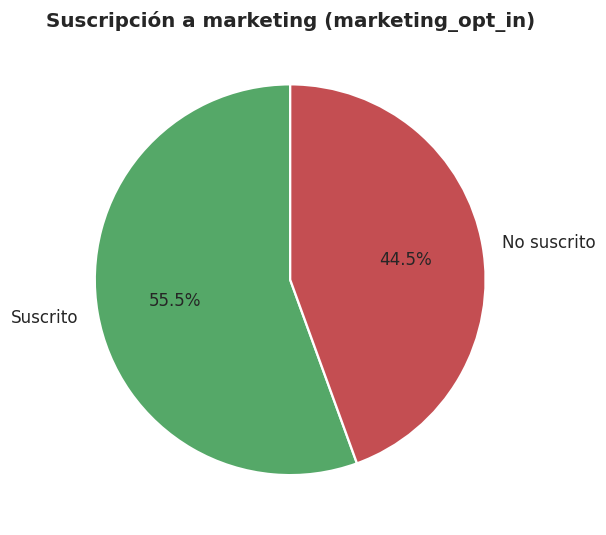

In [29]:
# Distribución de clientes según opt-in de marketing
opt_in = customers['marketing_opt_in'].value_counts()
print(opt_in)
print((opt_in / opt_in.sum() * 100).round(2))

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(opt_in.values, labels=['Suscrito' if v else 'No suscrito' for v in opt_in.index],
       autopct='%1.1f%%', colors=['#55A868', '#C44E52'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Suscripción a marketing (marketing_opt_in)', fontsize=13)
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** el **55.6% de los clientes** ha aceptado recibir comunicaciones de marketing, frente a un 44.5% que no.

**💡 Conclusión:** más de la mitad de la base es alcanzable directamente vía campañas de email/marketing, lo que representa una base sólida para activar comunicación directa; sin embargo, el 44.5% restante requerirá canales alternativos (por ejemplo, retargeting o redes sociales) para ser impactado.


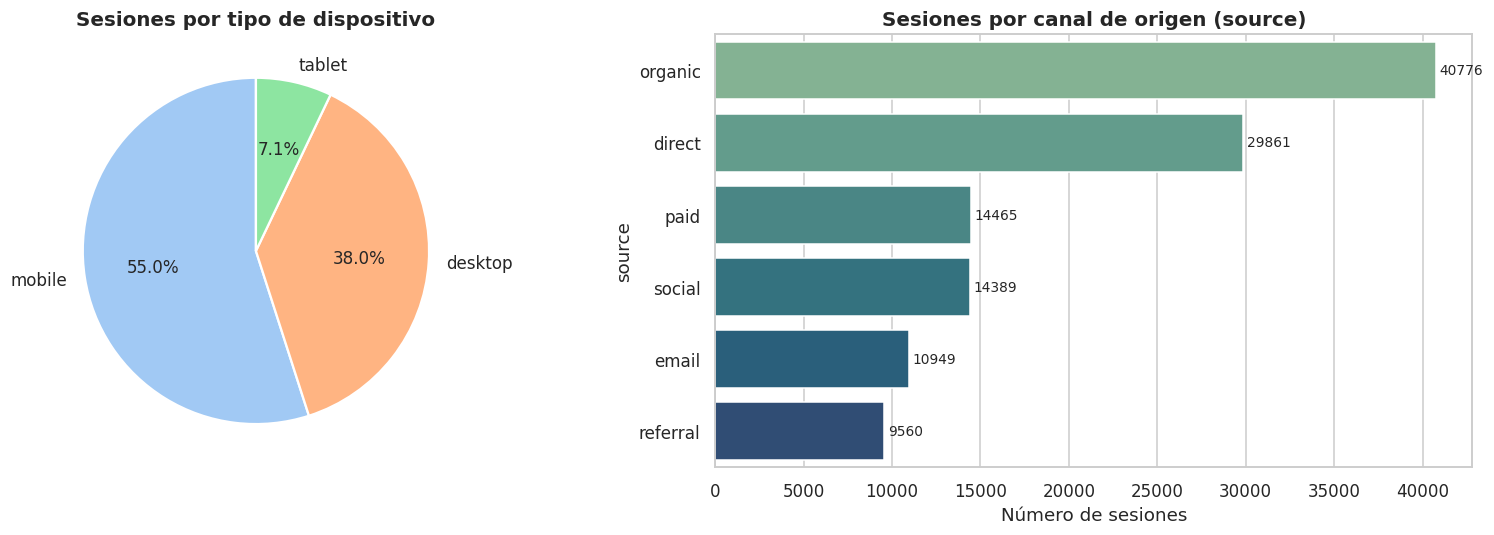

In [30]:
# Distribución de sesiones por tipo de dispositivo y por canal de origen
device_counts = sessions['device'].value_counts()
source_counts = sessions['source'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel')[:3], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Sesiones por tipo de dispositivo', fontsize=13)

sns.barplot(x=source_counts.values, y=source_counts.index, hue=source_counts.index,
            palette='crest', legend=False, ax=axes[1])
axes[1].set_title('Sesiones por canal de origen (source)', fontsize=13)
axes[1].set_xlabel('Número de sesiones')
for i, v in enumerate(source_counts.values):
    axes[1].text(v + 200, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()


**💡 Insight de negocio:** el **55%** de las sesiones ocurre desde **mobile**, 38% desde desktop y solo 7% desde tablet — el cliente típico navega principalmente desde su teléfono. En cuanto al canal, el tráfico **orgánico (34%)** y **directo (25%)** dominan sobre el pago (12%), social (12%), email (9%) y referidos (8%).

**💡 Conclusión:** la experiencia mobile debe ser prioridad de inversión en UX/performance, dado que concentra más de la mitad del tráfico. Además, la fuerte dependencia del tráfico orgánico y directo (59% combinado) es positiva para el costo de adquisición, pero también sugiere una oportunidad de crecimiento incremental si se invierte más en canales pagos y de email, actualmente subrepresentados.


### 2.1.8 Estadísticas descriptivas — resumen consolidado


In [31]:
# Resumen estadístico consolidado de las variables numéricas clave
resumen = df[['age', 'n_sessions']].describe().round(2)
resumen.loc['skew'] = df[['age', 'n_sessions']].skew().round(3)
resumen


,age,n_sessions
count,20000.000,20000.000
mean,46.490,6.000
std,16.770,2.470
min,18.000,0.000
25%,32.000,4.000
50%,46.500,6.000
75%,61.000,8.000
max,75.000,17.000
skew,0.002,0.423


**💡 Análisis técnico:** el coeficiente de asimetría (`skew`) de `age` es cercano a 0, confirmando la distribución uniforme/simétrica ya observada. `n_sessions` también tiene una asimetría baja, consistente con una distribución en forma de campana sin colas extremas.


### 2.1.9 Top clientes con más sesiones


In [32]:
# Top 10 clientes con mayor número de sesiones
top10 = sesiones_por_cliente.sort_values(ascending=False).head(10).reset_index()
top10.columns = ['customer_id', 'n_sessions']
top10 = top10.merge(customers[['customer_id', 'name', 'country', 'age']], on='customer_id', how='left')
top10


,customer_id,n_sessions,name,country,age
0,14088,17,Kenneth Moore,US,24
1,8374,16,Laura Fisher,US,63
2,3314,16,Julie Anderson,GB,44
3,19098,16,Carrie Alvarez,AU,65
4,14816,16,Jorge Pena,ES,59
5,3391,16,Carlos Goodman,AU,54
6,14687,16,David Chen,US,39
7,3953,16,Nathan Richardson,IN,71
8,2345,16,Raymond Murphy,BR,22
9,17718,16,Monique Howard,IN,40


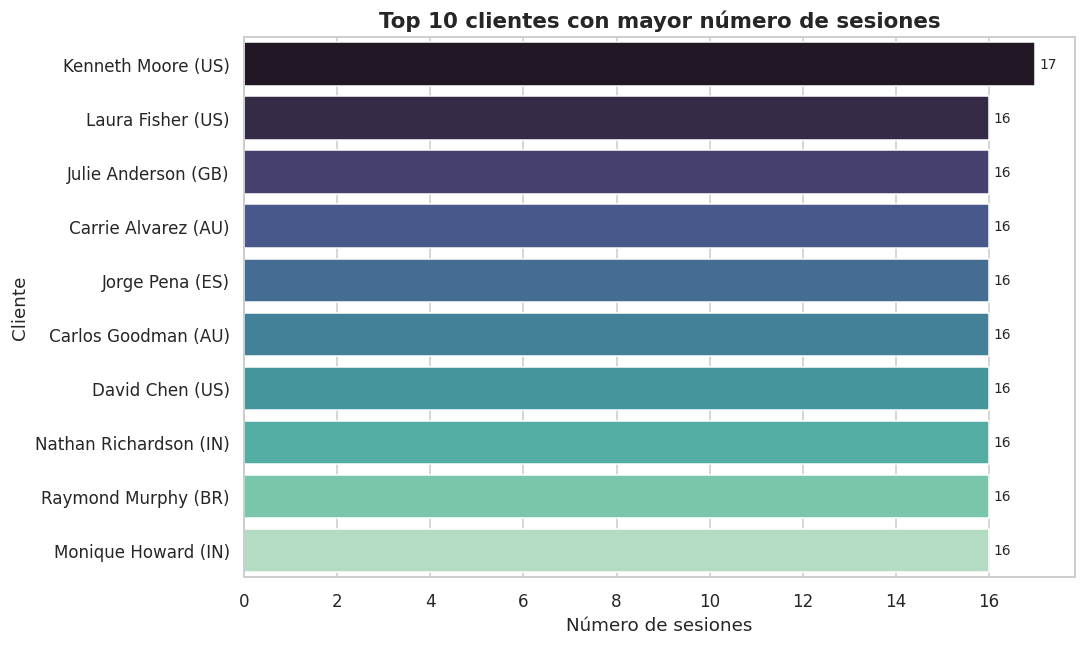

In [33]:
# Gráfico del Top 10
top10['label'] = top10['name'] + ' (' + top10['country'] + ')'
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='n_sessions', y='label', hue='label', data=top10, palette='mako', legend=False, ax=ax)
ax.set_title('Top 10 clientes con mayor número de sesiones', fontsize=14)
ax.set_xlabel('Número de sesiones')
ax.set_ylabel('Cliente')
for i, v in enumerate(top10['n_sessions']):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** el cliente más activo (Kenneth Moore, EE.UU.) registra 17 sesiones, y el resto del Top 10 se mueve entre 16 sesiones, repartido entre varios países (US, GB, AU, ES, IN, BR) y sin concentrarse en un único grupo de edad (22 a 71 años). No hay un "super cliente" que domine desproporcionadamente por encima del resto — la diferencia entre el 1° y el 10° lugar es de apenas 1 sesión.

**💡 Conclusión:** la actividad más alta está bien distribuida geográfica y demográficamente, lo cual es positivo: el negocio no depende de un puñado de clientes hiperactivos concentrados en un solo mercado.


### 2.1.10 Matriz de correlación

### Explicación técnica
Solo existen dos variables numéricas continuas propiamente dichas en el dataset consolidado: `age` y `n_sessions` (más `marketing_opt_in`, convertible a 0/1). Se calcula la correlación de Pearson entre ellas.


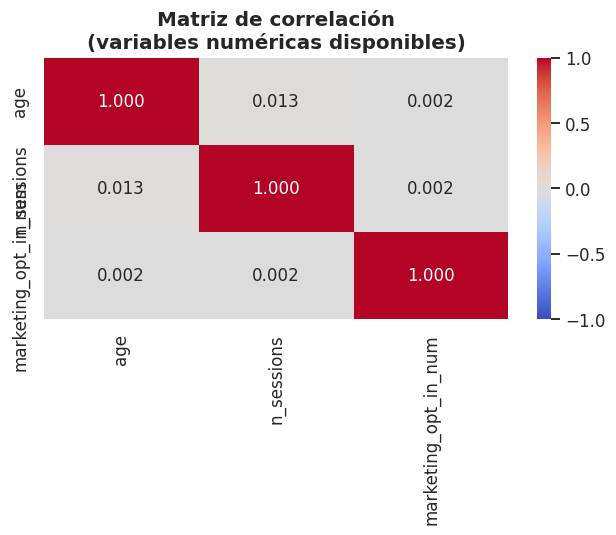

,age,n_sessions,marketing_opt_in_num
age,1.000000,0.013268,0.002309
n_sessions,0.013268,1.000000,0.001916
marketing_opt_in_num,0.002309,0.001916,1.000000


In [34]:
# Matriz de correlación entre las variables numéricas disponibles
df['marketing_opt_in_num'] = df['marketing_opt_in'].astype(int)
corr = df[['age', 'n_sessions', 'marketing_opt_in_num']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de correlación\n(variables numéricas disponibles)', fontsize=13)
plt.tight_layout()
plt.show()

corr


**💡 Análisis técnico:** todas las correlaciones son **prácticamente nulas** (valores absolutos menores a 0.02). No existe relación lineal entre la edad y el número de sesiones, ni entre la suscripción a marketing y ninguna de las otras dos variables.

**💡 Conclusión:** la edad **no predice** el nivel de actividad del cliente en el sitio, y aceptar recibir marketing tampoco se asocia con mayor o menor navegación. Esto refuerza el hallazgo de la Sección 2.1: la base de clientes es homogénea en comportamiento independientemente del perfil demográfico, por lo que **la segmentación por edad no es, por sí sola, un buen predictor de engagement** con los datos actualmente disponibles. **Advertencia:** esta matriz está limitada por el bajo número de variables numéricas en el dataset; una tabla de transacciones aportaría variables (gasto, frecuencia de compra) mucho más relevantes para este análisis.


### 2.1.11 Verificación adicional: coherencia geográfica sesión-cliente


In [35]:
# ¿Las sesiones se originan desde el mismo país en el que el cliente está registrado?
merged_geo = sessions.merge(customers[['customer_id', 'country']], on='customer_id',
                             suffixes=('_sesion', '_cliente'))
tasa_coincidencia = (merged_geo['country_sesion'] == merged_geo['country_cliente']).mean()
print(f"Porcentaje de sesiones cuyo país coincide con el país de registro del cliente: {tasa_coincidencia*100:.2f}%")


Porcentaje de sesiones cuyo país coincide con el país de registro del cliente: 100.00%


**💡 Análisis técnico:** el 100% de las sesiones se origina desde el mismo país en el que el cliente está registrado (`sessions.country` == `customers.country` en todos los casos).

**Insight de negocio / calidad de datos:** esto significa que, en este dataset, el campo `country` de `sessions.csv` **es redundante** respecto al país del cliente — no aporta información sobre viajes, VPN o navegación desde el extranjero, algo esperable en un dataset sintético generado para fines educativos. En un dataset real de producción, se esperaría encontrar cierto porcentaje de discordancia (clientes viajando, usando VPN, etc.), por lo que **esta uniformidad perfecta es también una señal de que los datos fueron simulados** y no debe interpretarse como un hallazgo de comportamiento real de los clientes.


---
## Conclusiones: ¿Quién compra?

### Hallazgos principales

1. **Calidad de datos excelente:** 0% de valores nulos, 0 duplicados en llaves primarias, e integridad referencial del 100% entre `sessions.csv` y `customers.csv` (20,000 clientes, 120,000 sesiones).
2. **Base de clientes demográficamente uniforme:** la edad se distribuye de forma pareja entre 18 y 75 años (media 46.5, sin atípicos), sin un segmento etario dominante.
3. **Huella global con concentración moderada:** 17 países; EE.UU. lidera con 18.2% de los clientes, seguido de India, Reino Unido, Brasil y Alemania (juntos, ~45% de la base).
4. **Sin columna de género:** no se pudo realizar este análisis porque la variable no existe en los datos entregados.
5. **Adquisición de clientes estable:** las altas mensuales se mantienen constantes desde 2020 hasta 2025, sin picos de crecimiento ni caídas abruptas; solo 4.2% de la base es "nueva" (últimos 90 días del corte de datos).
6. **Engagement recurrente:** en promedio, cada cliente activo genera 6.0 sesiones; el 25.7% de la base (5,133 clientes) son "clientes frecuentes" con 8+ sesiones.
7. **55 clientes (0.28%) nunca generaron una sesión** tras registrarse — abandono temprano post-registro.
8. **Mobile-first:** 55% de las sesiones ocurren desde dispositivo móvil; el tráfico orgánico y directo concentran el 59% de las visitas.
9. **Sin correlación relevante** entre edad, número de sesiones y aceptación de marketing (todas las correlaciones < 0.02 en valor absoluto).
10. **Limitación estructural clave:** no existe tabla de transacciones; por lo tanto, "quién compra" se responde en términos de perfil de cliente y comportamiento de navegación, **no de compra real**.

### Insights encontrados

- La base de clientes es **transversal y sin sesgos demográficos marcados** (ni por edad ni, previsiblemente, por otras variables no disponibles como género), lo que sugiere un producto o categoría de e-commerce con atractivo generalizado.
- El **nivel de actividad en el sitio no depende de la edad**, contradiciendo el supuesto habitual de que los segmentos más jóvenes navegan más.
- La **redundancia perfecta entre el país del cliente y el país de la sesión** (100% de coincidencia) indica que este es un dataset sintético y que ese campo, en esta versión de los datos, no aporta señal adicional sobre movilidad geográfica.
- El **25.7% de clientes frecuentes** es el activo de mayor valor potencial identificado en este análisis, aun sin poder confirmar con datos si esa actividad se traduce en ingresos.

### 🎯 Oportunidades de negocio

- **Priorizar experiencia mobile:** con más de la mitad del tráfico en móvil, cualquier fricción en esa plataforma tiene el mayor impacto posible sobre la base de clientes.
- **Programas de fidelización para el 25.7% de clientes frecuentes:** son el segmento de mayor interacción y candidato natural a campañas de retención y upsell.
- **Reactivación de los 55 clientes sin sesiones:** volumen pequeño pero de bajo costo de activar (ya están registrados y con email disponible).
- **Diversificar canales de adquisición:** actualmente el tráfico pagado (12%) y de email (9%) son minoritarios frente al orgánico/directo (59%); hay espacio para escalar inversión en canales pagos si el objetivo es crecer más rápido que el ritmo orgánico actual.
- **Aprovechar el 55.6% de clientes suscritos a marketing** para campañas directas, mientras se diseñan estrategias alternativas (social, retargeting) para alcanzar al 44.4% restante.

### Recomendaciones

1. **Solicitar la tabla de transacciones/pedidos** del dataset original de Kaggle (o del sistema fuente) para poder responder la pregunta de negocio de forma directa: quién compra, cuánto y con qué frecuencia. El análisis actual es un sustituto parcial basado en comportamiento de navegación, no de compra.
2. Si se dispone de más variables de cliente en el futuro (género, ciudad, segmento), incorporarlas para enriquecer la segmentación.
3. Cruzar, en fases posteriores del proyecto integrador, `n_sessions` con datos de conversión (cuando estén disponibles) para validar si el engagement de navegación efectivamente predice la compra.
4. Monitorear la tendencia de altas mensuales de clientes; al ser estable pero no creciente, cualquier objetivo de expansión requerirá una inversión incremental en adquisición.
5. Dar seguimiento específico al grupo de 55 clientes registrados sin actividad, para entender causas de abandono temprano (encuestas, análisis cualitativo).

### Conclusión de la sección

Con los datos disponibles (`customers.csv` y `sessions.csv`), es posible construir un **perfil sólido y confiable de quién es el cliente y cómo navega la plataforma**: una base global, demográficamente uniforme, mobile-first, con adquisición estable y un núcleo de ~26% de clientes altamente comprometidos. Sin embargo, la pregunta de negocio *"¿quién compra?"* **no puede responderse en sentido estricto** sin una tabla de transacciones, ya que ninguna de las dos tablas entregadas contiene información de compra, gasto o conversión. Este informe deja documentada esa limitación de forma explícita y entrega, como mejor aproximación posible con los datos actuales, un perfil detallado del cliente y su comportamiento de navegación — listo para ser complementado en próximas fases del proyecto integrador.

## 2.2 🛒 ¿Qué productos se venden?

Complementando el análisis de clientes de la sección anterior, esta sección se centra en el **catálogo de productos** (`products.csv`) y en las **líneas de venta** (`order_items.csv`) para caracterizar la oferta comercial del negocio. A diferencia de `customers.csv` y `sessions.csv`, aquí sí se dispone de información de transacciones reales (`order_items`), lo que permite hablar de ventas en sentido estricto y no solo de comportamiento de navegación.

**Objetivo:** responder cuatro preguntas de negocio a partir de datos reales — qué categorías de productos se venden, cómo se comportan los precios, qué márgenes deja cada categoría y qué productos concentran más ventas (en unidades e ingresos).



### Fuentes de datos

Se reutilizan `products` y `order_items`, ya cargados por el notebook oficial:

- **`products.csv`** — catálogo de productos (1,197 filas, 6 columnas).
- **`order_items.csv`** — líneas de venta (59,163 filas, 5 columnas).

#### Diccionario de datos — `products.csv`

| # | Columna | Tipo (pandas) | Tipo real de negocio | Descripción |
|---|---|---|---|---|
| 1 | `product_id` | int64 | Identificador único | Llave primaria del producto. Sin duplicados (1,197 valores únicos). |
| 2 | `category` | object (str) | Categórica | Categoría del producto. 7 categorías: `Electronics`, `Home & Kitchen`, `Beauty`, `Sports`, `Fashion`, `Books`, `Toys` (171 productos cada una). |
| 3 | `name` | object (str) | Texto | Nombre del producto (dato sintético). |
| 4 | `price_usd` | float64 | Numérica continua | Precio de venta en USD. Rango: 3.50 – 596.62. |
| 5 | `cost_usd` | float64 | Numérica continua | Costo del producto en USD. Rango: 2.21 – 446.10. |
| 6 | `margin_usd` | float64 | Numérica continua | Margen en USD (`price_usd − cost_usd`). Rango: 1.03 – 263.73. |

*Columna derivada dentro del notebook (no viene en el CSV):* `margin_pct` = `margin_usd / price_usd × 100`, calculada en la primera celda de código de esta sección y usada en el resto del análisis.

#### Diccionario de datos — `order_items.csv`

| # | Columna | Tipo (pandas) | Tipo real de negocio | Descripción |
|---|---|---|---|---|
| 1 | `order_id` | int64 | Identificador de pedido | Pedido al que pertenece la línea. No es único por fila (un pedido puede tener varias líneas de producto): 33,580 pedidos distintos en 59,163 líneas. |
| 2 | `product_id` | int64 | Llave foránea | Referencia a `products.product_id`. Aparecen 1,195 de los 1,197 productos del catálogo (2 productos del catálogo nunca fueron vendidos). |
| 3 | `unit_price_usd` | float64 | Numérica continua | Precio unitario al momento de la venta. Rango: 3.50 – 596.62. |
| 4 | `quantity` | int64 | Numérica discreta | Unidades vendidas en esa línea. Rango: 1 – 4. |
| 5 | `line_total_usd` | float64 | Numérica continua | Importe total de la línea. Se verificó que `line_total_usd = unit_price_usd × quantity` se cumple en el 100% de las 59,163 filas. |

**Nota de calidad de datos:** ambos archivos tienen **0 valores nulos**. `products.csv` no tiene filas ni `product_id` duplicados. `order_items.csv` no incluye un identificador propio de línea (`order_item_id`), y se detectaron **73 filas completamente duplicadas (0.12% del total)**; no es posible confirmar si corresponden a líneas de carrito legítimamente repetidas (mismo producto agregado dos veces) o a registros duplicados, ya que no existe una clave que las distinga. No se eliminaron ni se modificó ningún cálculo por este motivo — el volumen es marginal y no altera los resultados ni las conclusiones de la sección.

In [36]:
products.head()

,product_id,category,name,price_usd,cost_usd,margin_usd
0,1,Electronics,SSD MediumBlue 149,570.28,352.69,217.59
1,2,Electronics,Keyboard DeepPink 696,498.13,263.13,235.00
2,3,Electronics,Headphones Orchid 188,548.53,309.60,238.93
3,4,Electronics,Smartwatch BurlyWood 664,268.36,153.56,114.80
4,5,Electronics,Smartwatch Cornsilk 328,63.69,42.65,21.04


### 2.2.1 ¿Qué categorías de productos hay?

**Explicación técnica:** se calcula el margen porcentual por producto (`margin_pct = margin_usd / price_usd`, usado en las siguientes subsecciones) y se cuenta el número de productos por categoría en el catálogo.


In [37]:
# Margen en % por producto (se usa en las secciones siguientes)
products['margin_pct'] = products['margin_usd'] / products['price_usd'] * 100

print("Productos por categoría:")
print(products['category'].value_counts())

Productos por categoría:
category
Electronics       171
Home & Kitchen    171
Beauty            171
Sports            171
Fashion           171
Books             171
Toys              171
Name: count, dtype: int64


**💡 Insight de negocio:** el catálogo está organizado en **7 categorías** (`Electronics`, `Home & Kitchen`, `Beauty`, `Sports`, `Fashion`, `Books`, `Toys`), con exactamente **171 productos cada una** (1,197 productos en total).

**💡 Conclusión:** el catálogo está **perfectamente balanceado** entre categorías, por lo que ninguna diferencia observada más adelante (en precio, margen o ventas) responde a un sesgo de muestreo — todas las categorías parten del mismo número de productos.

### 2.2.2 ¿Cómo se comportan los precios?

**Explicación técnica:** se calculan estadísticas descriptivas de `price_usd` (conteo, media, mínimo, máximo) agrupadas por categoría, y se visualiza el precio promedio de cada una.

                count        mean    min     max
category                                        
Electronics       171  315.573450  30.13  596.62
Sports            171  154.192573   9.97  299.44
Home & Kitchen    171  125.179064  10.91  249.07
Fashion           171  109.852222   9.69  199.64
Beauty            171   64.656550   5.50  119.56
Toys              171   43.879532   6.51   79.83
Books             171   26.212807   3.50   49.97


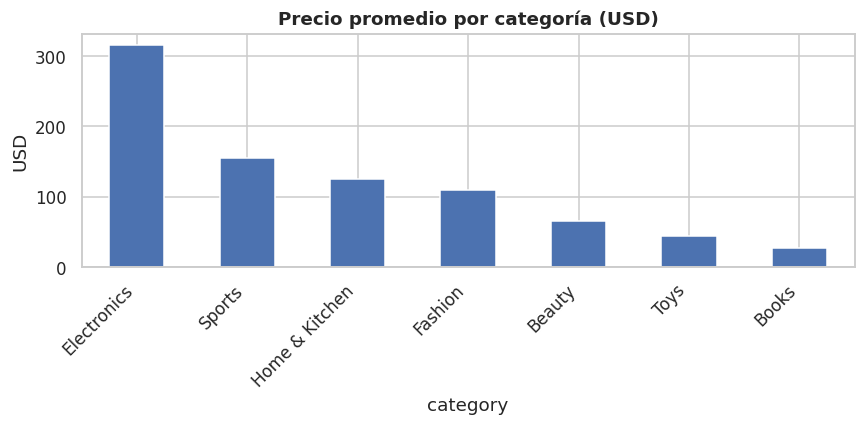

In [38]:
price_by_cat = products.groupby('category')['price_usd'].agg(['count', 'mean', 'min', 'max']).sort_values('mean', ascending=False)
print(price_by_cat)

price_by_cat['mean'].plot(kind='bar', figsize=(8, 4), title='Precio promedio por categoría (USD)')
plt.ylabel('USD')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**💡 Insight de negocio:** `Electronics` es, por lejos, la categoría más cara (precio promedio ≈ **USD 316**, con productos de hasta USD 597), más del doble que la siguiente (`Sports`, ≈ USD 154). `Books` es la más económica (≈ USD 26 en promedio, entre USD 3.50 y USD 50).

**💡 Conclusión:** existe una **brecha de precio muy marcada** entre categorías. Esto es clave al comparar categorías en ingresos o unidades vendidas más adelante: una categoría puede vender pocas unidades y aun así generar mucho ingreso (o viceversa), simplemente por su nivel de precio.

### 2.2.3 ¿Cuáles son los márgenes de los productos?

**Explicación técnica:** se calcula el margen promedio en dólares y en porcentaje por categoría (`margin_usd`, `margin_pct`), junto con el margen global del catálogo.

                margin_usd_mean  margin_pct_mean
category                                        
Electronics          113.997018        36.709541
Home & Kitchen        44.557778        35.742613
Beauty                23.153567        35.346109
Books                  9.249649        35.283160
Sports                52.232982        34.816398
Fashion               37.846023        34.576746
Toys                  15.123801        34.033852

Margen global:
  Precio promedio: $119.94
  Costo promedio:  $77.63
  Margen promedio: $42.31 (35.22%)


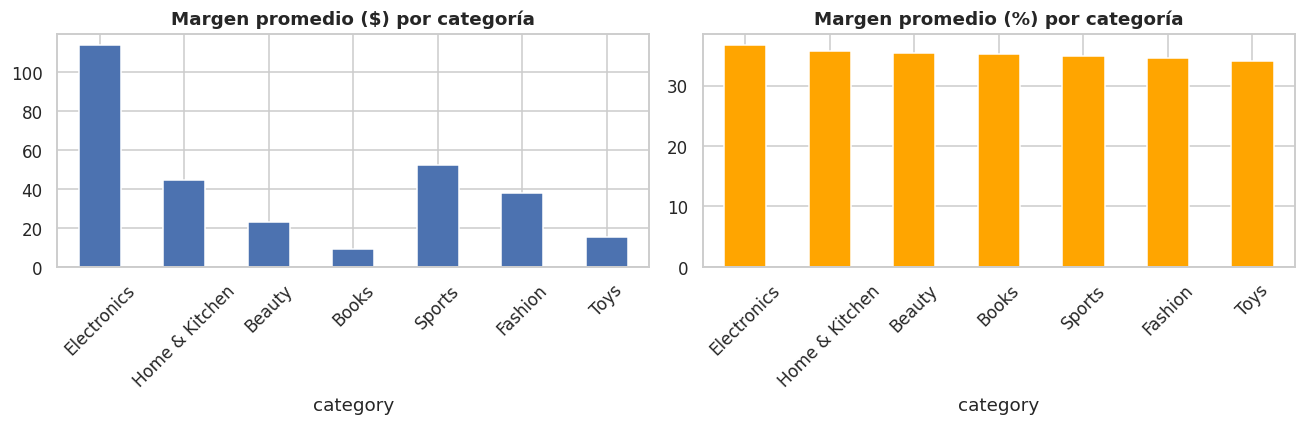

In [39]:
margin_by_cat = products.groupby('category').agg(
    margin_usd_mean=('margin_usd', 'mean'),
    margin_pct_mean=('margin_pct', 'mean')
).sort_values('margin_pct_mean', ascending=False)
print(margin_by_cat)

print()
print("Margen global:")
print(f"  Precio promedio: ${products['price_usd'].mean():.2f}")
print(f"  Costo promedio:  ${products['cost_usd'].mean():.2f}")
print(f"  Margen promedio: ${products['margin_usd'].mean():.2f} ({products['margin_pct'].mean():.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
margin_by_cat['margin_usd_mean'].plot(kind='bar', ax=axes[0], title='Margen promedio ($) por categoría')
margin_by_cat['margin_pct_mean'].plot(kind='bar', ax=axes[1], title='Margen promedio (%) por categoría', color='orange')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**💡 Insight de negocio:** el margen porcentual es **muy parejo entre categorías** (entre 34% y 37%, contra un promedio global de 35.2%), lo que sugiere una política de pricing consistente (markup similar sobre el costo) más allá del rubro. En cambio, el margen en dólares sí varía fuerte: `Electronics` deja ≈ **USD 114 por unidad vendida**, casi el triple que `Sports` (≈ USD 52), simplemente porque parte de una base de precio más alta.

**💡 Conclusión:** para decisiones de rentabilidad conviene mirar el **margen en dólares, no solo el porcentaje**, porque con un markup similar entre categorías, las de precio alto (`Electronics`) son las que más aportan margen absoluto por unidad vendida.


### 2.2.4 ¿Cuáles son los productos con mayores ventas?

**Explicación técnica:** se une `order_items` con `products` por `product_id` para calcular, por producto, las unidades vendidas (`qty`) y los ingresos generados (`revenue`), y se construyen los rankings correspondientes.

#### Top 10 por unidades vendidas


Top 10 por unidades vendidas:
 product_id                            name       category  qty  revenue
        496          Lipstick LightBlue 766         Beauty  179  1553.72
        442          Lipstick RosyBrown 771         Beauty  167  1055.44
        926                 E-book Gray 372          Books  160   961.60
        404  Conditioner CornflowerBlue 855         Beauty  159  1198.86
        265           Vacuum LightCoral 663 Home & Kitchen  157  5389.81
       1063 Action Figure DarkTurquoise 818           Toys  153  1914.03
        944            E-book PeachPuff 118          Books  151  2865.98
       1170              Doll LightCyan 982           Toys  151  2793.50
       1087    Building Blocks DarkCyan 517           Toys  150  1186.50
       1028               Puzzle Orchid 600           Toys  150  1068.00


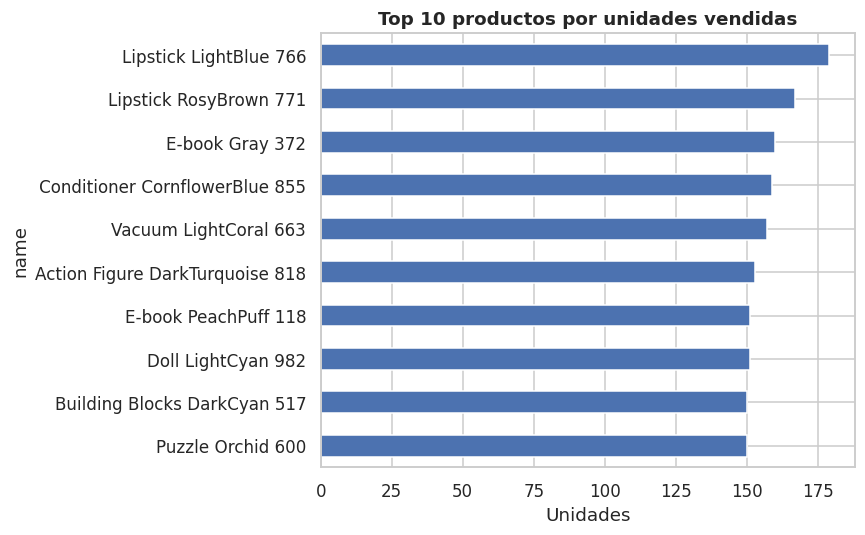

In [40]:
sales = order_items.groupby('product_id').agg(
    qty=('quantity', 'sum'),
    revenue=('line_total_usd', 'sum')
).reset_index()
sales = sales.merge(products, on='product_id')
sales['total_margin'] = sales['margin_usd'] * sales['qty']

top_qty = sales.sort_values('qty', ascending=False).head(10)
print("Top 10 por unidades vendidas:")
print(top_qty[['product_id', 'name', 'category', 'qty', 'revenue']].to_string(index=False))

top_qty.set_index('name')['qty'].plot(kind='barh', figsize=(8, 5), title='Top 10 productos por unidades vendidas')
plt.xlabel('Unidades')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**💡 Insight de negocio:** el top 10 por unidades está dominado por productos de `Beauty`, `Books` y `Toys` (categorías de precio bajo), con volúmenes entre 150 y 179 unidades. **Ningún producto de `Electronics` aparece en este ranking.**

**💡 Conclusión:** el volumen de ventas por sí solo **no es un buen indicador** de qué productos priorizar comercialmente, ya que favorece a los ítems más baratos sin reflejar su aporte real en ingresos o margen.

#### Top 10 por ingresos

Top 10 por ingresos:
 product_id                         name    category  qty  revenue
        104          Mouse RosyBrown 419 Electronics   55  9860.40
        120    Headphones Aquamarine 465 Electronics   16  9286.88
         51         Webcam LightBlue 848 Electronics   64  9212.80
          9         Mouse Chartreuse 292 Electronics  101  8962.74
        801    Hoodie BlanchedAlmond 225     Fashion   64  8874.24
        680  Tennis Racket PaleGreen 443      Sports   71  8778.44
        533 Cycling Helmet DarkKhaki 165      Sports   58  8709.28
        156      Smartwatch Moccasin 101 Electronics   41  8616.56
        657        Water Bottle Gold 746      Sports   45  8284.95
         87    Mouse MediumTurquoise 578 Electronics   47  8190.69


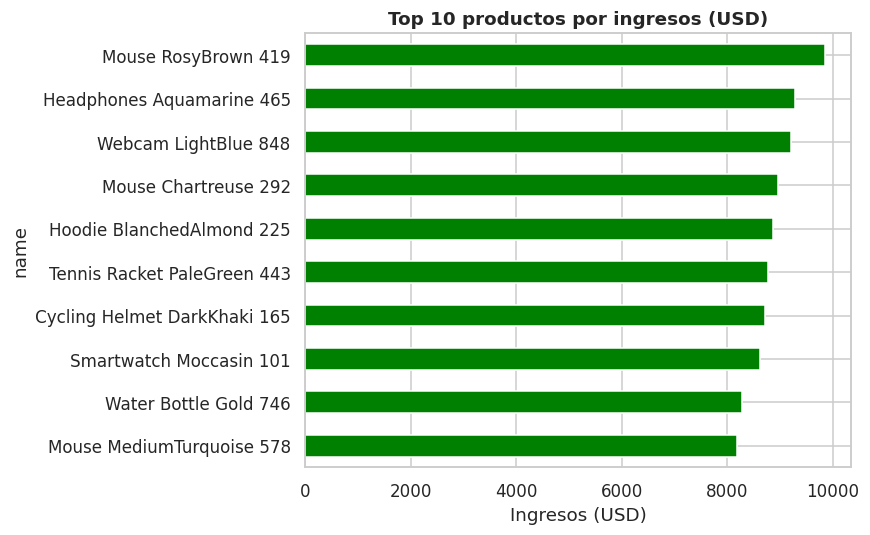

In [41]:
top_rev = sales.sort_values('revenue', ascending=False).head(10)
print("Top 10 por ingresos:")
print(top_rev[['product_id', 'name', 'category', 'qty', 'revenue']].to_string(index=False))

top_rev.set_index('name')['revenue'].plot(kind='barh', figsize=(8, 5), title='Top 10 productos por ingresos (USD)', color='green')
plt.xlabel('Ingresos (USD)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**💡 Insight de negocio:** el ranking por ingresos es **casi opuesto** al de unidades: lo dominan `Electronics` y `Sports` (6 de los 10 puestos), con productos que venden relativamente pocas unidades (16 a 101) pero a precio alto, generando entre USD 8,200 y USD 9,860 cada uno.

**💡 Conclusión:** confirma que **volumen e ingreso son señales distintas y potencialmente contradictorias**; una estrategia de catálogo o de stock debería mirar ambos rankings (y el de margen) antes de decidir qué productos priorizar.

#### Ventas e ingresos totales por categoría

                unidades   ingresos  margen_total
category                                         
Home & Kitchen      9461  840736.82     300634.79
Sports              8358  832349.63     293094.57
Fashion            10056  824739.33     287422.69
Electronics         4496  692866.07     257397.74
Beauty             13330  692312.49     245640.74
Toys               14875  569153.08     193954.48
Books              16530  383450.80     135152.65


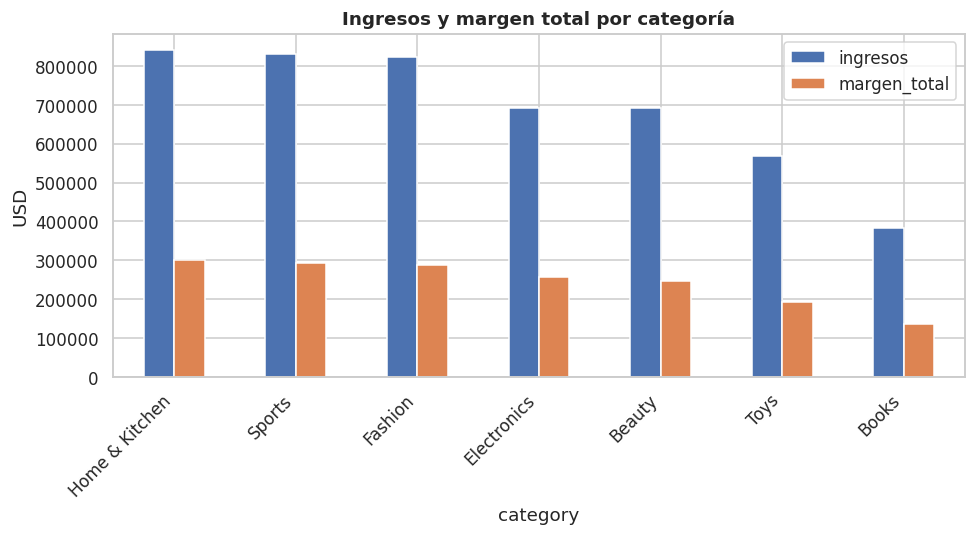

In [42]:
cat_summary = sales.groupby('category').agg(
    unidades=('qty', 'sum'),
    ingresos=('revenue', 'sum'),
    margen_total=('total_margin', 'sum')
).sort_values('ingresos', ascending=False)
print(cat_summary)

cat_summary[['ingresos', 'margen_total']].plot(kind='bar', figsize=(9, 5), title='Ingresos y margen total por categoría')
plt.ylabel('USD')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**💡 Insight de negocio:** `Home & Kitchen` lidera en ingresos totales (≈ USD 841k) y margen total (≈ USD 301k) pese a no ser la categoría más vendida en unidades. En el otro extremo, `Books` vende más unidades que nadie (16,530) pero genera el menor ingreso total (≈ USD 383k) por su precio bajo. `Electronics`, con el precio y margen % más altos, queda en el medio de la tabla en ingresos totales porque vende relativamente pocas unidades (4,496, la menor cantidad de todas las categorías).

**Análisis complementario — participación porcentual por categoría:** calculando la participación de cada categoría sobre el total de ingresos, margen y unidades vendidas (a partir de la tabla anterior), se obtiene:

| Categoría | % Ingresos | % Margen total | % Unidades |
|---|---|---|---|
| Home & Kitchen | 17.4% | 17.5% | 12.3% |
| Sports | 17.2% | 17.1% | 10.8% |
| Fashion | 17.1% | 16.8% | 13.0% |
| Electronics | 14.3% | 15.0% | 5.8% |
| Beauty | 14.3% | 14.3% | 17.3% |
| Toys | 11.8% | 11.3% | 19.3% |
| Books | 7.9% | 7.9% | 21.4% |

Esta tabla hace visible el mismo patrón de forma más directa: **Home & Kitchen, Sports y Fashion** concentran en conjunto cerca del **52% de los ingresos y del margen total** con solo el 36% de las unidades vendidas, mientras que **Toys y Books** concentran el 41% de las unidades pero menos del 20% de los ingresos.

**💡 Conclusión:** a nivel categoría, el ingreso total depende tanto del precio como del volumen, y **ninguna categoría domina en ambos ejes a la vez**. Esto es clave para priorizar inventario y foco comercial: maximizar solo precio (`Electronics`) o solo volumen (`Books`) no maximiza el ingreso total.

## Conclusiones: ¿Qué productos se venden?

1. **Categorías:** el catálogo tiene 7 categorías perfectamente balanceadas (171 productos cada una, 1,197 en total), por lo que las diferencias encontradas en precio, margen y ventas no responden a un sesgo de muestreo.
2. **Precios:** existe una brecha de precio muy marcada entre categorías — `Electronics` es la más cara (≈ USD 316 en promedio) y `Books` la más económica (≈ USD 26).
3. **Márgenes:** el markup porcentual es homogéneo entre categorías (34%-37%, promedio global 35.2%), pero el margen en dólares por unidad favorece claramente a las categorías de precio alto (`Electronics` ≈ USD 114 vs. `Sports` ≈ USD 52).
4. **Top ventas:** el ranking por unidades y el ranking por ingresos son casi opuestos — `Beauty`/`Books`/`Toys` lideran en volumen, `Electronics`/`Sports` lideran en ingresos por producto.
5. **Por categoría:** `Home & Kitchen`, `Sports` y `Fashion` concentran en conjunto ≈52% de los ingresos y del margen total con solo 36% de las unidades vendidas; `Electronics` tiene el mejor margen % pero el menor volumen; `Books` lidera en unidades pero no en ingresos.
6. **Recomendación:** cualquier decisión de catálogo, stock o foco comercial debería considerar **precio, margen y volumen en conjunto**, no una sola métrica aislada — priorizar solo por unidades (favorece a `Books`/`Toys`) o solo por precio (favorece a `Electronics`) lleva a conclusiones opuestas y potencialmente equivocadas sobre qué productos son realmente más valiosos para el negocio.

**Respuesta a las preguntas de negocio de esta sección:** el catálogo vende de forma balanceada entre 7 categorías; los precios y márgenes en dólares están concentrados en `Electronics`; el volumen de ventas está concentrado en `Books`/`Toys`/`Beauty`; y los mayores ingresos por categoría los generan `Home & Kitchen`, `Sports` y `Fashion`, que combinan un volumen razonable con precios medios-altos.


## 2.3 🛍️ ¿Cómo compran?

Continuando con el catálogo de productos de la sección anterior, esta sección se centra en el **comportamiento de compra**: el recorrido que sigue una sesión desde que visita una página hasta que concreta (o abandona) una compra. Se utilizan `events.csv` (clickstream con cada evento de navegación y compra) y `orders.csv` (pedidos confirmados), cruzados con `sessions.csv` para incorporar dispositivo, fuente de tráfico y país.

**Objetivo:** responder cuatro preguntas de negocio — cómo es el embudo de compra (funnel), cómo se comporta el *add to cart*, cómo se comporta el *checkout*, y cómo finaliza la *purchase* — e identificar en qué etapa se concentra la mayor fricción del proceso.


### Fuentes de datos

#### Diccionario de datos — `events.csv`

| # | Columna | Tipo (pandas) | Descripción |
|---|---|---|---|
| 1 | `event_id` | int64 | Identificador único del evento. Sin duplicados (760,958 valores únicos). |
| 2 | `session_id` | int64 | Llave foránea hacia `sessions.session_id`. Integridad referencial 100% (0 huérfanos). |
| 3 | `timestamp` | datetime | Momento del evento. Rango: 2020-01-01 a 2025-11-01. |
| 4 | `event_type` | categórica | Etapa del funnel: `page_view` (539,343) / `add_to_cart` (143,126) / `checkout` (44,909) / `purchase` (33,580). |
| 5 | `product_id` | float64 | Producto asociado al evento. Poblado solo en `page_view` y `add_to_cart`. |
| 6 | `qty` | float64 | Unidades agregadas. Poblado solo en `add_to_cart`. |
| 7 | `cart_size` | float64 | Tamaño del carrito en ese momento. Poblado solo en `checkout`. |
| 8 | `payment` | object | Método de pago (`card`/`paypal`/`wallet`/`cod`). Poblado solo en `purchase`. |
| 9 | `discount_pct` | float64 | % de descuento aplicado. Poblado solo en `purchase`. |
| 10 | `amount_usd` | float64 | Monto de la compra en USD. Poblado solo en `purchase`. |

**Nota:** las columnas 5 a 10 tienen muchos valores nulos, pero son **nulos estructurales, no un problema de calidad** — cada columna solo aplica a la etapa del funnel donde tiene sentido (por ejemplo, `amount_usd` no existe en un `page_view` porque todavía no hay compra). Esto se confirma en la sección 2.3.1.

#### Diccionario de datos — `orders.csv`

| # | Columna | Tipo (pandas) | Descripción |
|---|---|---|---|
| 1 | `order_id` | int64 | Identificador único del pedido. Sin duplicados (33,580 valores únicos). |
| 2 | `customer_id` | int64 | Llave foránea hacia `customers.customer_id`. Integridad referencial 100% (0 huérfanos). |
| 3 | `order_time` | datetime | Fecha y hora del pedido. Rango: 2020-01-01 a 2025-10-31. |
| 4 | `payment_method` | categórica | `card` / `paypal` / `wallet` / `cod`. |
| 5 | `discount_pct` | int64 | % de descuento del pedido. Rango: 0 – 20. |
| 6 | `subtotal_usd` | float64 | Subtotal antes de descuento. Rango: 3.50 – 3,141.66. |
| 7 | `total_usd` | float64 | Total pagado después de descuento. Rango: 2.80 – 2,984.58. |
| 8 | `country` | categórica (ISO-2) | País del pedido (17 países). |
| 9 | `device` | categórica | `desktop` / `mobile` / `tablet`. |
| 10 | `source` | categórica | `organic` / `email` / `paid` / `direct` / `social` / `referral`. |

**Calidad de datos:** ambos archivos tienen **0 valores nulos estructurales fuera de lo esperado, 0 filas duplicadas y 0 llaves foráneas huérfanas** (`orders.customer_id` → `customers`, `events.session_id` → `sessions`). `orders.csv` tiene exactamente **33,580 pedidos**, el mismo número que eventos `purchase` en `events.csv` — es decir, cada compra finalizada en el funnel corresponde a un pedido registrado, lo que permite usar ambas tablas de forma complementaria en la sección de *Purchase*.

### 2.3.1 Funnel de compra: visión general

**Explicación técnica:** se filtran los eventos correspondientes a las cuatro etapas del funnel (`page_view`, `add_to_cart`, `checkout`, `purchase`) y se cuentan las **sesiones únicas** que alcanzaron cada etapa — no el número de eventos, ya que una misma sesión puede generar varios eventos del mismo tipo (por ejemplo, ver varias páginas).


In [43]:
# Distribución de eventos por tipo (760,958 eventos en total)
events["event_type"].value_counts()

event_type
page_view      539343
add_to_cart    143126
checkout        44909
purchase        33580
Name: count, dtype: int64

In [44]:
# 1. Definición de las etapas del funnel y filtrado de eventos relevantes
funnel_steps = ["page_view", "add_to_cart", "checkout", "purchase"]
funnel = events[events["event_type"].isin(funnel_steps)].copy()

# 2. Se incorpora el contexto de la sesión (device, source, country) en un único merge,
#    reutilizado por todas las subsecciones siguientes (funnel general, por dispositivo y por fuente)
funnel_with_session = funnel.merge(
    sessions[["session_id", "device", "source", "country"]],
    on="session_id",
    how="left"
)

# 3. Funnel general: sesiones únicas que alcanzaron cada etapa
funnel_sessions = (
    funnel_with_session.groupby("event_type")["session_id"]
    .nunique()
    .reindex(funnel_steps)
    .reset_index()
)
funnel_sessions.columns = ["etapa", "sesiones_unicas"]
funnel_sessions


,etapa,sesiones_unicas
0,page_view,120000
1,add_to_cart,81518
2,checkout,44909
3,purchase,33580


In [45]:
# Verificación de qué columnas están pobladas en cada etapa del funnel
# (confirma que los nulos de events.csv son estructurales, no un problema de calidad)
cols_interes = ["qty", "cart_size", "payment", "discount_pct", "amount_usd"]
resumen_eventos = funnel.groupby("event_type")[cols_interes].apply(lambda x: x.notna().sum())
resumen_eventos


,qty,cart_size,payment,discount_pct,amount_usd
event_type,,,,,
add_to_cart,143126,0,0,0,0
checkout,0,44909,0,0,0
page_view,0,0,0,0,0
purchase,0,0,33580,33580,33580


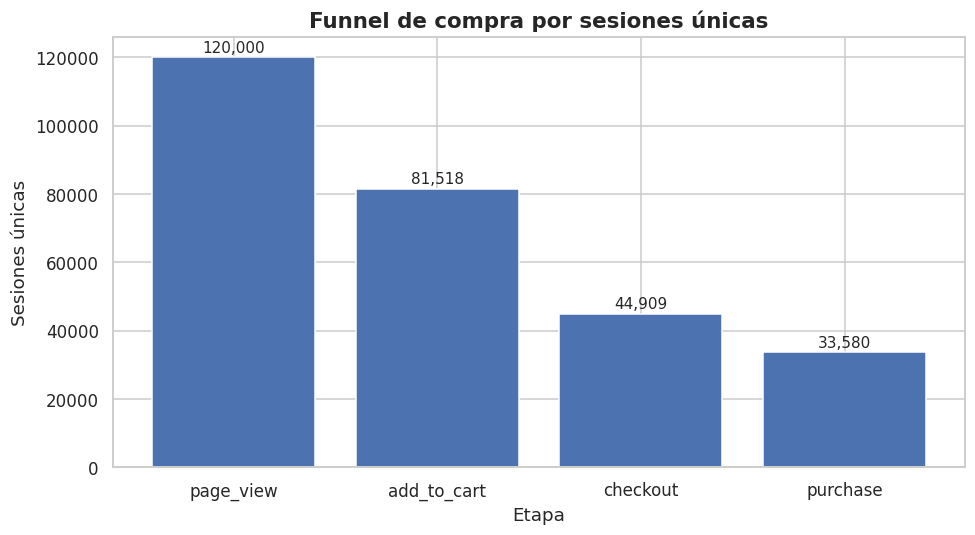

In [46]:
# Visualización del funnel general (sesiones únicas por etapa)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(funnel_sessions["etapa"], funnel_sessions["sesiones_unicas"], color="#4C72B0")
ax.set_title("Funnel de compra por sesiones únicas", fontsize=14)
ax.set_xlabel("Etapa")
ax.set_ylabel("Sesiones únicas")
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 1500, f"{h:,.0f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**💡 Insight de negocio:** de las 120,000 sesiones totales, **todas** registran al menos un `page_view`. A partir de ahí el embudo cae de forma progresiva: 81,518 sesiones agregan algo al carrito, 44,909 llegan a checkout y 33,580 concretan la compra. En paralelo, el sitio registra 760,958 eventos en total (539,343 solo de `page_view`), lo que indica que una sesión promedio navega varias páginas (~4.5) antes de decidir si agrega un producto al carrito.

In [47]:
# Sesiones (sets) por etapa — se reutilizan tanto para medir abandono como conversión
page_view_sessions   = set(funnel.loc[funnel["event_type"] == "page_view", "session_id"])
add_to_cart_sessions = set(funnel.loc[funnel["event_type"] == "add_to_cart", "session_id"])
checkout_sessions    = set(funnel.loc[funnel["event_type"] == "checkout", "session_id"])
purchase_sessions    = set(funnel.loc[funnel["event_type"] == "purchase", "session_id"])

# Abandono: sesiones que llegaron a una etapa pero no avanzaron a la siguiente
abandono_page = len(page_view_sessions - add_to_cart_sessions)
abandono_cart = len(add_to_cart_sessions - checkout_sessions)
abandono_checkout = len(checkout_sessions - purchase_sessions)

print(f"Sesiones que vieron página pero no agregaron al carrito: {abandono_page:,}")
print(f"Sesiones con add_to_cart que no llegaron a checkout: {abandono_cart:,}")
print(f"Sesiones con checkout que no compraron: {abandono_checkout:,}")


Sesiones que vieron página pero no agregaron al carrito: 38,482
Sesiones con add_to_cart que no llegaron a checkout: 36,609
Sesiones con checkout que no compraron: 11,329


In [48]:
# Conversión entre etapas consecutivas (a partir de los mismos sets ya calculados)
conversion_page_to_cart = len(add_to_cart_sessions) / len(page_view_sessions)
conversion_cart_to_checkout = len(checkout_sessions) / len(add_to_cart_sessions)
conversion_checkout_to_purchase = len(purchase_sessions) / len(checkout_sessions)
conversion_final = len(purchase_sessions) / len(page_view_sessions)

print(f"Conversión page_view -> add_to_cart: {conversion_page_to_cart:.2%}")
print(f"Conversión add_to_cart -> checkout: {conversion_cart_to_checkout:.2%}")
print(f"Conversión checkout -> purchase: {conversion_checkout_to_purchase:.2%}")
print(f"Conversión final page_view -> purchase: {conversion_final:.2%}")

Conversión page_view -> add_to_cart: 67.93%
Conversión add_to_cart -> checkout: 55.09%
Conversión checkout -> purchase: 74.77%
Conversión final page_view -> purchase: 27.98%


**💡 Insight de negocio:** la caída porcentual más fuerte del funnel ocurre entre **add_to_cart y checkout** (conversión de solo 55.1%, la más baja de las tres transiciones), por encima incluso de la caída inicial `page_view → add_to_cart` (67.9%). En cambio, una vez que una sesión llega a checkout, tiene una probabilidad alta (74.8%) de concretar la compra.

**💡 Conclusión:** el principal punto de fricción del proceso **no está en el pago final, sino en la transición entre "tengo algo en el carrito" y "empiezo a pagar"**. La conversión global page_view → purchase es de 27.98%: de cada 100 sesiones que navegan el sitio, 28 terminan comprando.


### 2.3.2 Add to Cart: ¿cuántas unidades agrega el usuario?

**Explicación técnica:** se analiza la columna `qty` (unidades agregadas por evento), disponible únicamente en los eventos `add_to_cart`.

In [49]:
# Unidades agregadas por evento de add_to_cart
qty_stats = funnel.loc[funnel["event_type"] == "add_to_cart", "qty"].describe()
qty_stats

count    143126.000000
mean          1.301748
std           0.783436
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: qty, dtype: float64

**💡 Insight de negocio:** en el 85% de los casos (mediana = 1) el usuario agrega **una sola unidad** por acción de "agregar al carrito" (promedio 1.30). Las cantidades de 2, 3 y 4 unidades se reparten de forma pareja entre el 15% restante, sin un patrón de compras masivas.

**💡 Conclusión:** el comportamiento de carga al carrito es mayormente unitario. Esto es consistente con un catálogo de productos individuales (no packs), y sugiere que estrategias de *cross-selling* ("agregá 2 y ahorrá") podrían tener espacio para aumentar el tamaño del carrito.


### 2.3.3 Checkout: tamaño del carrito

**Explicación técnica:** se analiza `cart_size` (cantidad de productos en el carrito), disponible únicamente en los eventos `checkout` — es la foto del carrito en el momento en que el usuario decide pagar.

In [50]:
# Tamaño del carrito en el momento del checkout
cart_summary = (
    funnel[funnel["cart_size"].notna()]
    .groupby("event_type")["cart_size"]
    .agg(["count", "mean", "median", "max"])
)
cart_summary

,count,mean,median,max
event_type,,,,
checkout,44909,2.286958,2.0,13.0


**💡 Insight de negocio:** el carrito promedio al llegar a checkout tiene **2.29 productos** (mediana 2), con un máximo observado de 13. Comparado con la sección anterior (mayoría de acciones de *add to cart* de 1 unidad), esto indica que **los usuarios suelen agregar productos en más de una acción** antes de pasar a pagar, no todo de una vez.

**💡 Conclusión:** el carrito típico es pequeño (2 productos). Sería valioso testear tácticas de *upsell* en el propio checkout (por ejemplo, "productos frecuentemente comprados juntos"), dado que hay margen entre el tamaño actual del carrito y lo que un cliente podría llevar.


### 2.3.4 Purchase: ¿cómo finaliza la compra?

**Explicación técnica:** se aísla el subconjunto de eventos `purchase` (`purchase_events`), reutilizado en todo el resto de esta subsección para evitar recalcularlo. Se analizan monto de compra, descuentos aplicados y método de pago (este último desde `orders.csv`, que registra un pedido por cada `purchase` del funnel).


In [51]:
# Definición única de purchase_events — se reutiliza en todo el resto de la sección
purchase_events = funnel[funnel["event_type"] == "purchase"].copy()

purchase_summary = purchase_events[["discount_pct", "amount_usd"]].describe()
purchase_summary

,discount_pct,amount_usd
count,33580.000000,33580.000000
mean,7.160214,133.806357
std,7.474901,152.130611
min,0.000000,2.800000
25%,0.000000,40.300000
50%,5.000000,86.460000
75%,15.000000,174.270000
max,20.000000,2984.580000


In [52]:
print(f"Ticket promedio: USD {purchase_events['amount_usd'].mean():.2f}")
print(f"Mediana del ticket: USD {purchase_events['amount_usd'].median():.2f}")
print(f"Compra máxima: USD {purchase_events['amount_usd'].max():.2f}")

Ticket promedio: USD 133.81
Mediana del ticket: USD 86.46
Compra máxima: USD 2984.58


In [53]:
# Compras con descuento aplicado
compras_con_desc = (purchase_events["discount_pct"] > 0).sum()
total_compras = len(purchase_events)
pct_compras_con_desc = compras_con_desc / total_compras * 100

print(f"Compras con descuento: {compras_con_desc:,} de {total_compras:,} ({pct_compras_con_desc:.2f}%)")
print(f"Descuento promedio en purchase: {purchase_events['discount_pct'].mean():.2f}%")


Compras con descuento: 19,327 de 33,580 (57.56%)
Descuento promedio en purchase: 7.16%


In [54]:
# Método de pago utilizado (orders.csv, complementa a events.csv que no distingue el medio de pago con detalle)
payment_dist = orders["payment_method"].value_counts()
payment_dist_pct = (orders["payment_method"].value_counts(normalize=True) * 100).round(2)

pd.DataFrame({"pedidos": payment_dist, "pct": payment_dist_pct})

,pedidos,pct
payment_method,,
card,23455,69.85
paypal,5032,14.99
wallet,3373,10.04
cod,1720,5.12


**💡 Insight de negocio:** el ticket promedio es de **USD 133.81** (mediana USD 86.46 — la diferencia indica una cola de compras de alto valor que empuja el promedio hacia arriba, hasta un máximo de USD 2,984.58). Más de la mitad de las compras (**57.6%**) incluye algún descuento, con un descuento promedio de 7.2 puntos porcentuales sobre el total de compras. En cuanto al medio de pago, **tarjeta domina con el 69.9%** de los pedidos, seguida de PayPal (15.0%), billetera digital (10.0%) y contra-entrega (5.1%).

**💡 Conclusión:** los descuentos están muy presentes en el cierre de la venta (más de la mitad de las compras los usa), lo que sugiere que son una palanca relevante de conversión en checkout. La concentración en tarjeta como medio de pago (70%) indica que cualquier fricción en ese método de pago específico tendría un impacto desproporcionado en el negocio.

### 2.3.5 Segmentación: funnel por dispositivo y por fuente de tráfico

**Explicación técnica:** se recalcula el funnel (sesiones únicas por etapa) desagregado por `device` y por `source`, agregando las mismas tasas de conversión entre etapas que en la visión general, para identificar si algún canal concentra más fricción que otros.


In [55]:
# Funnel por dispositivo, con las mismas tasas de conversión que el funnel general
funnel_device = (
    funnel_with_session
    .drop_duplicates(subset=["session_id", "event_type"])
    .groupby(["device", "event_type"])["session_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=funnel_steps, fill_value=0)
)
funnel_device["conv_view_to_cart_%"] = (funnel_device["add_to_cart"] / funnel_device["page_view"] * 100).round(2)
funnel_device["conv_cart_to_checkout_%"] = (funnel_device["checkout"] / funnel_device["add_to_cart"] * 100).round(2)
funnel_device["conv_checkout_to_purchase_%"] = (funnel_device["purchase"] / funnel_device["checkout"] * 100).round(2)
funnel_device["conv_final_%"] = (funnel_device["purchase"] / funnel_device["page_view"] * 100).round(2)
funnel_device

event_type,page_view,add_to_cart,checkout,purchase,conv_view_to_cart_%,conv_cart_to_checkout_%,conv_checkout_to_purchase_%,conv_final_%
device,,,,,,,,
desktop,45547,30990,17069,12750,68.04,55.08,74.70,27.99
mobile,65942,44800,24695,18469,67.94,55.12,74.79,28.01
tablet,8511,5728,3145,2361,67.30,54.91,75.07,27.74


In [56]:
# Funnel por fuente de tráfico, misma metodología que por dispositivo
funnel_source = (
    funnel_with_session
    .drop_duplicates(subset=["session_id", "event_type"])
    .groupby(["source", "event_type"])["session_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=funnel_steps, fill_value=0)
)
funnel_source["conv_view_to_cart_%"] = (funnel_source["add_to_cart"] / funnel_source["page_view"] * 100).round(2)
funnel_source["conv_cart_to_checkout_%"] = (funnel_source["checkout"] / funnel_source["add_to_cart"] * 100).round(2)
funnel_source["conv_checkout_to_purchase_%"] = (funnel_source["purchase"] / funnel_source["checkout"] * 100).round(2)
funnel_source["conv_final_%"] = (funnel_source["purchase"] / funnel_source["page_view"] * 100).round(2)
funnel_source


event_type,page_view,add_to_cart,checkout,purchase,conv_view_to_cart_%,conv_cart_to_checkout_%,conv_checkout_to_purchase_%,conv_final_%
source,,,,,,,,
direct,29861,20380,11269,8387,68.25,55.29,74.43,28.09
email,10949,7412,4111,3056,67.70,55.46,74.34,27.91
organic,40776,27580,15137,11268,67.64,54.88,74.44,27.63
paid,14465,9854,5442,4121,68.12,55.23,75.73,28.49
referral,9560,6513,3574,2724,68.13,54.87,76.22,28.49
social,14389,9779,5376,4024,67.96,54.97,74.85,27.97


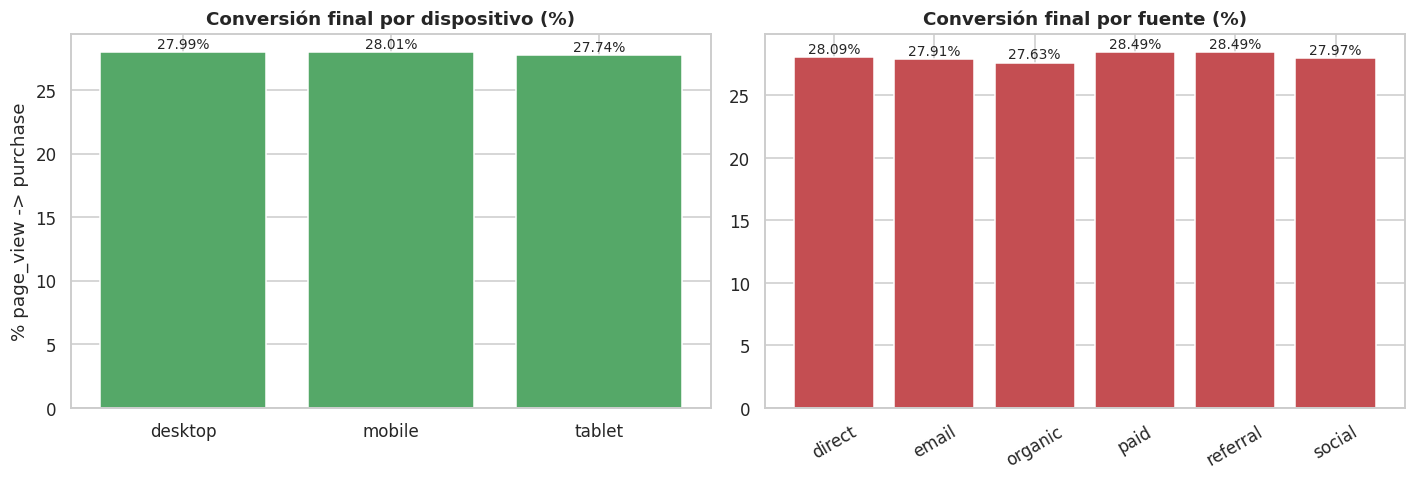

In [57]:
# Comparación visual de la conversión final (page_view -> purchase) por canal
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(funnel_device.index, funnel_device["conv_final_%"], color="#55A868")
axes[0].set_title("Conversión final por dispositivo (%)")
axes[0].set_ylabel("% page_view -> purchase")
for i, v in enumerate(funnel_device["conv_final_%"]):
    axes[0].text(i, v + 0.3, f"{v}%", ha="center", fontsize=9)

axes[1].bar(funnel_source.index, funnel_source["conv_final_%"], color="#C44E52")
axes[1].set_title("Conversión final por fuente (%)")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(funnel_source["conv_final_%"]):
    axes[1].text(i, v + 0.3, f"{v}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


**💡 Insight de negocio:** la conversión final varía muy poco entre dispositivos (27.7% tablet, 28.0% desktop, 28.0% mobile) y entre fuentes (27.6% orgánico hasta 28.5% en pago y referidos). Ninguna categoría se desvía más de 1 punto porcentual del promedio general (27.98%).

**💡 Conclusión:** la fricción identificada en la sección 2.3.1 (la caída entre add_to_cart y checkout) es **estructural y transversal a todos los canales**, no un problema puntual de un dispositivo o fuente de tráfico específica. Esto refuerza que la oportunidad de mejora está en el flujo de carrito → checkout en sí mismo, más que en optimizar un canal de adquisición en particular.


## Conclusiones: ¿Cómo compran?

1. **Funnel:** de 120,000 sesiones, 81,518 agregan un producto al carrito, 44,909 llegan a checkout y 33,580 compran — una conversión final de 27.98%.
2. **Mayor fricción:** la caída porcentual más marcada ocurre entre *add to cart* y *checkout* (conversión de 55.1%, la más baja del funnel), no en el pago final — una vez en checkout, el 74.8% concreta la compra.
3. **Add to Cart:** el 85% de las acciones de agregar al carrito son de una sola unidad (mediana = 1, promedio 1.30).
4. **Checkout:** el carrito promedio al momento de pagar es de 2.29 productos (mediana 2), lo que indica que el carrito se arma con varias acciones de *add to cart* individuales.
5. **Purchase:** ticket promedio de USD 133.81 (mediana USD 86.46); 57.6% de las compras incluye descuento; tarjeta es el medio de pago dominante (69.9%).
6. **Segmentación:** la conversión final es prácticamente uniforme entre dispositivos y fuentes de tráfico (todas dentro de ±1 punto porcentual del promedio) — la fricción del funnel es estructural, no depende del canal.

**Respuesta a las preguntas de negocio de esta sección:** el embudo pierde más usuarios entre el carrito y el checkout que en cualquier otra etapa; el *add to cart* es mayormente de una unidad; el *checkout* típico llega con 2 productos; y la *purchase* se concreta con un ticket promedio de USD 134, fuertemente influenciada por descuentos y pagada mayormente con tarjeta. La oportunidad de mejora más clara es **reducir la fricción entre carrito y checkout**, ya que es ahí donde se concentra el mayor abandono y donde el canal de adquisición no explica la diferencia.

## 2.4 💬 ¿Qué opinan los usuarios?

Esta sección cierra el EDA respondiendo qué opinan los usuarios sobre los productos que compran (`reviews.csv`), y complementa esa pregunta con una **validación de coherencia entre todas las tablas del proyecto** y la **preparación de la matriz usuario-producto** que va a alimentar el sistema de recomendación de la siguiente fase. Se incluye este alcance ampliado porque son verificaciones transversales (no específicas de una sola sección) que le dan sustento técnico a todo el EDA, y porque la matriz usuario-producto es el puente natural entre el EDA y el modelado.

**Objetivo:** responder qué opinan los usuarios (distribución de ratings, relación con precio/categoría), confirmar que las tablas del proyecto son consistentes entre sí, y dejar cuantificada la información que el sistema de recomendación va a necesitar (dispersión de la matriz usuario-producto, productos con pocas interacciones).



### Fuentes de datos

Se reutilizan `customers`, `sessions`, `events`, `orders`, `order_items` y `products` (ya cargados por el notebook oficial), y se incorpora una tabla nueva:

#### Diccionario de datos — `reviews.csv`

| # | Columna | Tipo (pandas) | Descripción |
|---|---|---|---|
| 1 | `review_id` | int64 | Identificador único de la reseña. |
| 2 | `order_id` | int64 | Llave foránea hacia `orders.order_id`. |
| 3 | `product_id` | int64 | Llave foránea hacia `products.product_id`. |
| 4 | `rating` | int64 | Calificación de 1 a 5 estrellas. |
| 5 | `review_text` | object | Comentario de texto asociado al rating. |
| 6 | `review_time` | object (se convierte a datetime) | Fecha de la reseña. |

**Nota:** `events`, `orders`, `reviews`, `customers` y `sessions` llegan con sus columnas de fecha en formato texto — el notebook oficial no las convierte a `datetime` al cargarlas. Esta sección hace esa conversión (con `convertir_columnas_fecha` de `utils.py`) para las columnas que necesita.


### 2.4.1 Calidad de datos y coherencia entre tablas

**Explicación técnica:** se valida la integridad referencial de todas las relaciones llave foránea → llave primaria del proyecto (reutilizando `verificar_integridad_referencial` de `utils.py`), se confirma que el número de compras en `events.csv` coincide con `orders.csv`, se buscan duplicados, y se verifica la coherencia temporal entre `signup_date`, `order_time` y `review_time` (una fecha de reseña no debería ser anterior a la compra que reseña, ni una compra anterior al registro del cliente).


In [58]:
# Funciones reutilizables del proyecto (ver auditoría de utils.py)
from utils import (
    verificar_integridad_referencial,
    calcular_sets_eventos_sesion,
    convertir_columnas_fecha,
)

In [59]:
# Conversión de columnas de fecha (una única vez, para toda la sección)
events = convertir_columnas_fecha(events, ["timestamp"])
orders = convertir_columnas_fecha(orders, ["order_time"])
reviews = convertir_columnas_fecha(reviews, ["review_time"])
customers = convertir_columnas_fecha(customers, ["signup_date"])

In [60]:
# Integridad referencial de todas las relaciones del proyecto
print("=== INTEGRIDAD REFERENCIAL ===")
print(f"Orders con customer_id inválido: "
      f"{verificar_integridad_referencial(orders, 'customer_id', customers, 'customer_id')}")
print(f"Order_items con order_id inválido: "
      f"{verificar_integridad_referencial(order_items, 'order_id', orders, 'order_id')}")
print(f"Order_items con product_id inválido: "
      f"{verificar_integridad_referencial(order_items, 'product_id', products, 'product_id')}")
print(f"Reviews con order_id inválido: "
      f"{verificar_integridad_referencial(reviews, 'order_id', orders, 'order_id')}")
print(f"Reviews con product_id inválido: "
      f"{verificar_integridad_referencial(reviews, 'product_id', products, 'product_id')}")
print(f"Sessions con customer_id inválido: "
      f"{verificar_integridad_referencial(sessions, 'customer_id', customers, 'customer_id')}")


=== INTEGRIDAD REFERENCIAL ===
Orders con customer_id inválido: 0
Order_items con order_id inválido: 0
Order_items con product_id inválido: 0
Reviews con order_id inválido: 0
Reviews con product_id inválido: 0
Sessions con customer_id inválido: 0


In [61]:
# Sincronía entre eventos de purchase y pedidos registrados
n_purchases_events = (events["event_type"] == "purchase").sum()
n_orders = len(orders)
print(f"Eventos purchase: {n_purchases_events:,} | Pedidos en orders.csv: {n_orders:,} "
      f"| Coinciden: {n_purchases_events == n_orders}")


Eventos purchase: 33,580 | Pedidos en orders.csv: 33,580 | Coinciden: True


In [62]:
# Duplicados
print(f"Events duplicados exactos: {events.duplicated().sum()}")

reviews_dup_exactas = reviews.duplicated(subset=["order_id", "product_id", "rating"]).sum()
reviews_dup_par = reviews.duplicated(subset=["order_id", "product_id"], keep=False).sum()
reviews_contradictorias = reviews_dup_par - reviews_dup_exactas
print(f"Reviews duplicadas exactas (mismo order+product+rating): {reviews_dup_exactas}")
print(f"Reviews contradictorias (mismo order+product, rating distinto): {reviews_contradictorias}")

Events duplicados exactos: 0
Reviews duplicadas exactas (mismo order+product+rating): 4
Reviews contradictorias (mismo order+product, rating distinto): 26


In [63]:
# Coherencia temporal entre tablas
rev_ord = reviews.merge(orders[["order_id", "order_time"]], on="order_id")
pct_review_antes_de_orden = (rev_ord["review_time"] < rev_ord["order_time"]).mean() * 100

ord_signup = orders.merge(customers[["customer_id", "signup_date"]], on="customer_id")
pct_orden_antes_de_signup = (ord_signup["order_time"] < ord_signup["signup_date"]).mean() * 100

print(f"Reviews con review_time anterior a su order_time: {pct_review_antes_de_orden:.1f}%")
print(f"Pedidos con order_time anterior al signup_date del cliente: {pct_orden_antes_de_signup:.1f}%")


Reviews con review_time anterior a su order_time: 50.9%
Pedidos con order_time anterior al signup_date del cliente: 50.4%


**💡 Insight de negocio:** la integridad referencial es del **100%** en las 6 relaciones verificadas (0 filas huérfanas), y el número de eventos `purchase` coincide exactamente con el número de pedidos en `orders.csv` (sincronía perfecta entre ambas tablas). Se detectan **4 reviews duplicadas exactas** y **26 reviews contradictorias** (mismo pedido y producto, pero rating distinto).

**Hallazgo crítico para todo el proyecto:** aproximadamente la **mitad de las reviews (≈51%) tienen fecha anterior a la orden que reseñan**, y **≈50% de los pedidos tienen fecha anterior al registro del cliente que los hizo**. Esto viola la cadena causal esperada (`signup_date ≤ order_time ≤ review_time`) y confirma que las fechas del dataset fueron generadas de forma aleatoria, no realista.

**💡 Conclusión:** ningún equipo del proyecto debería construir *features* temporales (antigüedad del cliente, tiempo entre compra y reseña, recencia) ni usar un split entrenamiento/prueba basado en fechas, mientras esta inconsistencia no se corrija en el origen de los datos. Es el hallazgo de calidad de datos más importante de todo el EDA porque afecta directamente el diseño del modelo de recomendación.


### 2.4.2 Reviews: distribución de ratings y comentarios

**Explicación técnica:** se analiza la distribución de `rating` y de `review_text` en `reviews.csv`.

=== RATINGS ===
rating
1     423
2     757
3    1980
4    3565
5    4055
Name: count, dtype: int64

Rating promedio: 3.93/5
% con 4 o 5 estrellas: 70.7%


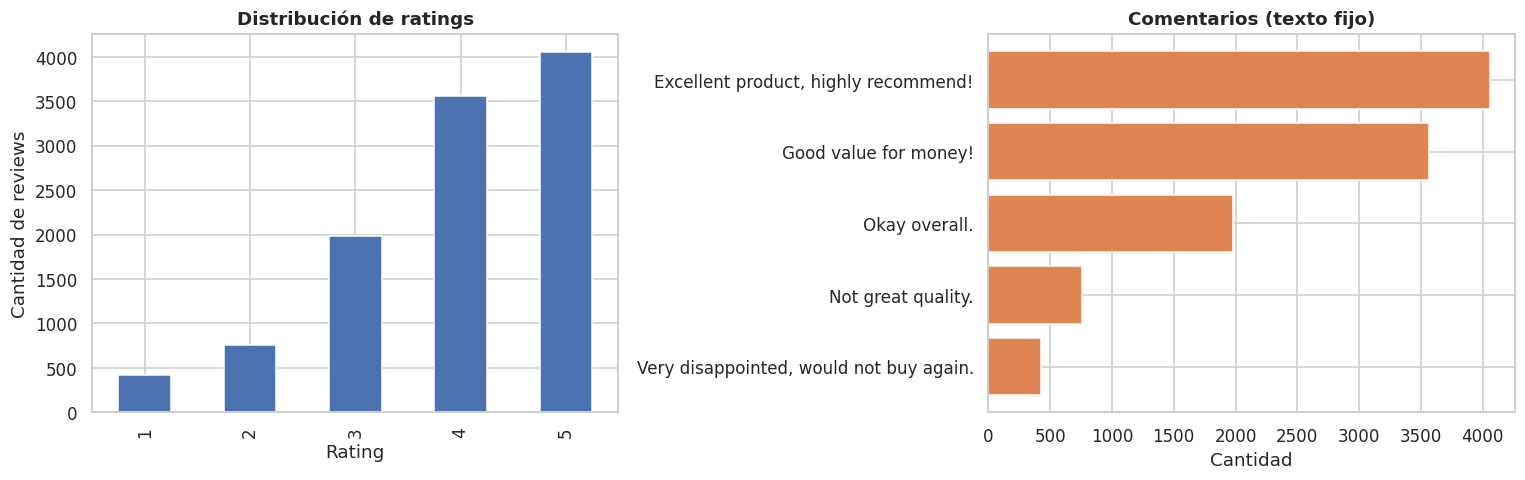


Frases de review distintas: 5 (de 10,780 reviews)


In [64]:
# Distribución de ratings
print("=== RATINGS ===")
print(reviews["rating"].value_counts().sort_index())
print(f"\nRating promedio: {reviews['rating'].mean():.2f}/5")
print(f"% con 4 o 5 estrellas: {(reviews['rating'] >= 4).mean()*100:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

reviews["rating"].value_counts().sort_index().plot(kind="bar", ax=ax1, color="#4C72B0")
ax1.set_title("Distribución de ratings")
ax1.set_xlabel("Rating")
ax1.set_ylabel("Cantidad de reviews")

orden_frases = [
    "Very disappointed, would not buy again.",
    "Not great quality.",
    "Okay overall.",
    "Good value for money!",
    "Excellent product, highly recommend!",
]
conteo_frases = reviews["review_text"].value_counts().reindex(orden_frases)
ax2.barh(orden_frases, conteo_frases.values, color="#DD8452")
ax2.set_title("Comentarios (texto fijo)")
ax2.set_xlabel("Cantidad")

plt.tight_layout()
plt.show()

print(f"\nFrases de review distintas: {reviews['review_text'].nunique()} (de {len(reviews):,} reviews)")


**💡 Insight de negocio:** el rating promedio es **3.93/5**, con una distribución sesgada hacia calificaciones altas — **70.7% de las reviews son de 4 o 5 estrellas**. `review_text` tiene únicamente **5 frases fijas**, cada una asociada 1 a 1 con un valor de `rating` (por ejemplo, todo rating=5 tiene el texto *"Excellent product, highly recommend!"*).

**💡 Conclusión:** al ser texto fijo y redundante con `rating`, **no es viable aplicar NLP** sobre `review_text` — no aporta información que `rating` no tenga ya. Para el sistema de recomendación, `rating` es la única señal de satisfacción utilizable de esta tabla.


### 2.4.3 ¿Qué influye en el rating? Precio y categoría

**Explicación técnica:** se cruza `reviews` con `products` para evaluar si el precio o la categoría del producto se relacionan con el rating recibido.

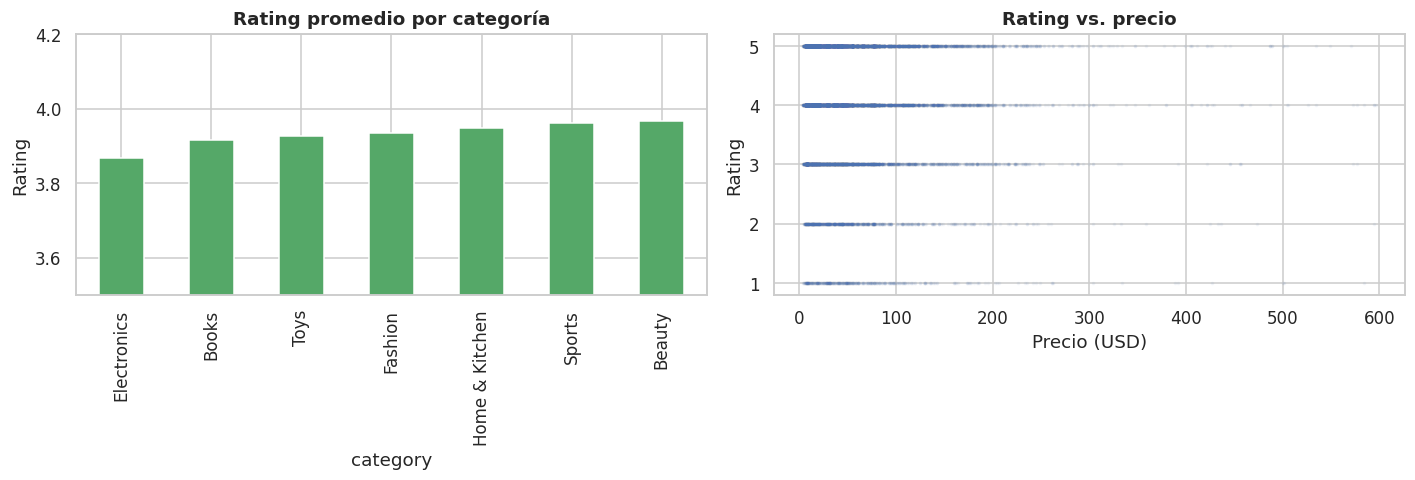

Correlación precio-rating: 0.0005


In [65]:
# Rating por categoría y relación rating-precio
reviews_productos = reviews.merge(products[["product_id", "category", "price_usd"]], on="product_id")
rating_por_categoria = reviews_productos.groupby("category")["rating"].mean().sort_values()
correlacion_precio_rating = reviews_productos["price_usd"].corr(reviews_productos["rating"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

rating_por_categoria.plot(kind="bar", ax=ax1, color="#55A868")
ax1.set_title("Rating promedio por categoría")
ax1.set_ylabel("Rating")
ax1.set_ylim(3.5, 4.2)

ax2.scatter(reviews_productos["price_usd"], reviews_productos["rating"], alpha=0.05, s=2, color="#4C72B0")
ax2.set_title("Rating vs. precio")
ax2.set_xlabel("Precio (USD)")
ax2.set_ylabel("Rating")
ax2.set_yticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

print(f"Correlación precio-rating: {correlacion_precio_rating:.4f}")


**💡 Insight de negocio:** la correlación entre precio y rating es **prácticamente nula** (r=0.0005), y el rating promedio por categoría se mueve en un rango angosto (3.87 a 3.97 sobre 5) — de `Electronics` (la más cara) a `Beauty` (una de las más económicas) la satisfacción reportada es prácticamente la misma.

**💡 Conclusión:** ni el precio ni la categoría explican la satisfacción del usuario en este dataset. Para el modelo de recomendación, esto significa que **el rating debe tratarse como una señal independiente del precio**, no como un proxy de "producto caro = mejor valorado".


### 2.4.4 Estructura y evolución temporal de `events.csv`

**Explicación técnica:** se describen las cuatro variables numéricas de `events.csv`, cada una poblada solo en la etapa del funnel a la que corresponde (`amount_usd` y `discount_pct` en `purchase`, `qty` en `add_to_cart`, `cart_size` en `checkout`), y se revisa si el volumen de eventos es estable en el tiempo.

       amount_usd (purchase)  discount_pct (purchase)  qty (add_to_cart)  cart_size (checkout)
count               33580.00                 33580.00          143126.00              44909.00
mean                  133.81                     7.16               1.30                  2.29
std                   152.13                     7.47               0.78                  1.61
min                     2.80                     0.00               1.00                  1.00
25%                    40.30                     0.00               1.00                  1.00
50%                    86.46                     5.00               1.00                  2.00
75%                   174.27                    15.00               1.00                  3.00
max                  2984.58                    20.00               4.00                 13.00


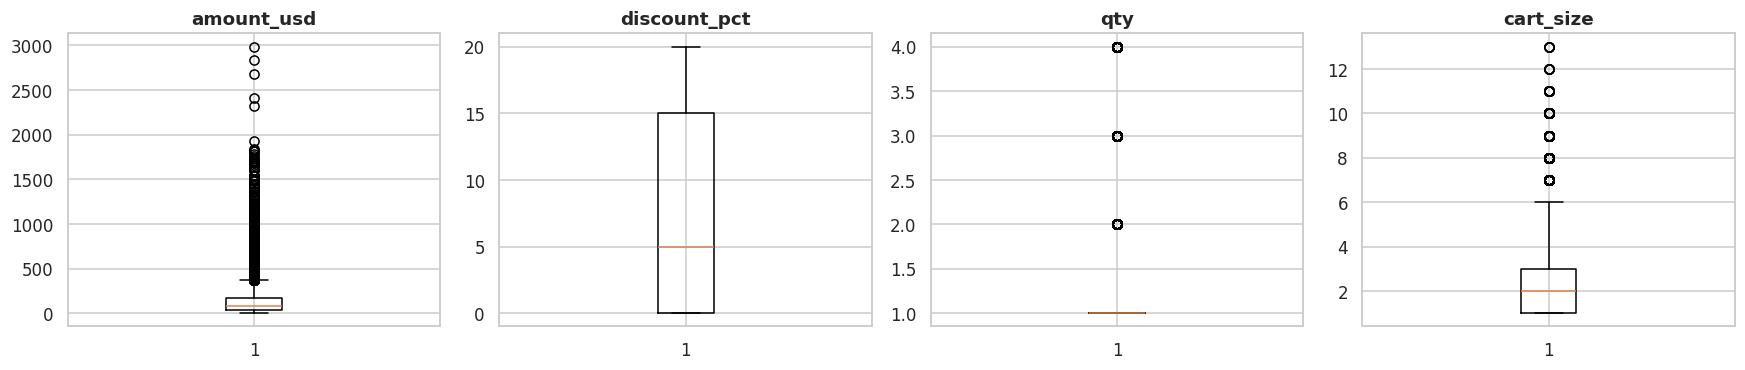

In [66]:
# Distribución de las variables numéricas de events.csv, cada una en su etapa correspondiente
add_to_cart_events = events[events["event_type"] == "add_to_cart"]
checkout_events = events[events["event_type"] == "checkout"]
purchase_events = events[events["event_type"] == "purchase"]

amount = purchase_events["amount_usd"]
discount = purchase_events["discount_pct"]
qty = add_to_cart_events["qty"]
cart_size = checkout_events["cart_size"]

print(pd.DataFrame({
    "amount_usd (purchase)": amount.describe(),
    "discount_pct (purchase)": discount.describe(),
    "qty (add_to_cart)": qty.describe(),
    "cart_size (checkout)": cart_size.describe(),
}).round(2))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, serie, titulo in zip(axes, [amount, discount, qty, cart_size],
                              ["amount_usd", "discount_pct", "qty", "cart_size"]):
    ax.boxplot(serie.dropna())
    ax.set_title(titulo)
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** `amount_usd` tiene una distribución asimétrica hacia la derecha, con un máximo (USD 2,984) muy por encima de la mediana (USD 86) — algunos pedidos grandes empujan el promedio hacia arriba. `qty` se concentra casi toda en 1 unidad (máximo 4) y `cart_size` promedia 2.3 productos (máximo 13), consistente con lo ya visto en la sección de Carina.

**💡 Conclusión:** si `amount_usd` se usa como *feature* o variable objetivo en el modelo, conviene evaluar winsorizar en el percentil 99 para reducir la influencia de esos pedidos atípicos sin descartarlos.

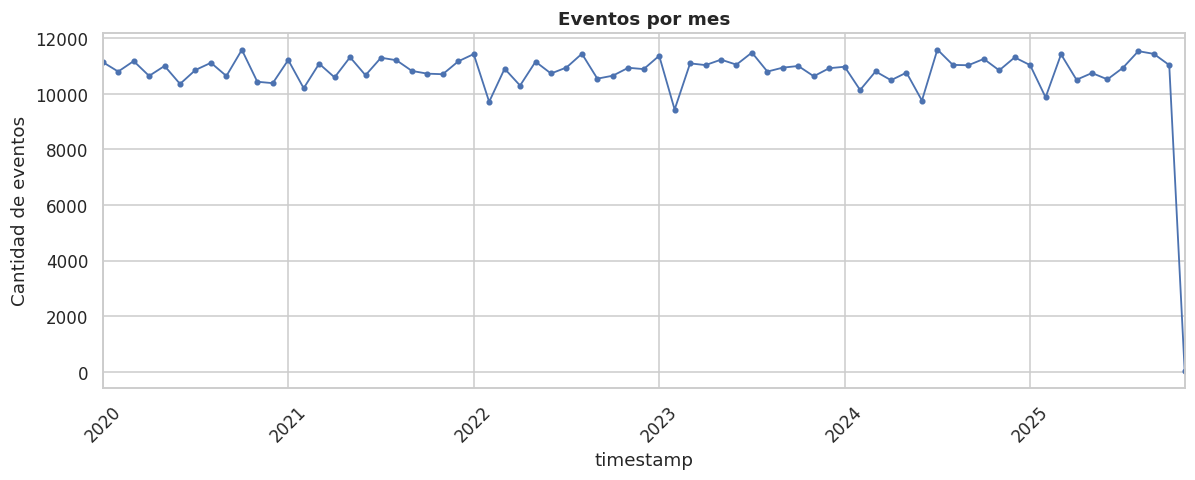

Total: 760,958 eventos | Promedio: 10718/mes (desvío 1363)


In [67]:
# Evolución mensual del volumen de eventos
eventos_por_mes = events.groupby(events["timestamp"].dt.to_period("M")).size()

fig, ax = plt.subplots(figsize=(11, 4.5))
eventos_por_mes.plot(ax=ax, marker="o", markersize=3, color="#4C72B0", linewidth=1.2)
ax.set_title("Eventos por mes")
ax.set_ylabel("Cantidad de eventos")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"Total: {len(events):,} eventos | Promedio: {eventos_por_mes.mean():.0f}/mes "
      f"(desvío {eventos_por_mes.std():.0f})")

**💡 Insight de negocio:** el volumen de eventos es estable a lo largo de todo el periodo (~10,700 eventos/mes en promedio), sin estacionalidad ni tendencia de crecimiento.

**💡 Conclusión:** la ausencia de estacionalidad (por ejemplo, picos en fechas comerciales) refuerza que se trata de un dataset sintético — es una limitación a tener en cuenta si se quiere modelar demanda estacional más adelante.

### 2.4.5 Conversión por dispositivo, fuente y país

**Explicación técnica:** se marca cada sesión como "con compra" o "sin compra" (a partir de `calcular_sets_eventos_sesion` de `utils.py`) y se compara la tasa de conversión por dispositivo, fuente de tráfico y país. La sección 2.3.5 (Carina) ya mostró esto por dispositivo y fuente — aquí se reutiliza esa misma lógica y se **agrega el corte por país**, que no estaba cubierto.

In [68]:
# Sesiones marcadas con compra o no, a partir de los sets de eventos por sesión
eventos_por_sesion = calcular_sets_eventos_sesion(events)

sesiones = pd.DataFrame({"session_id": eventos_por_sesion.index})
sesiones["compro"] = eventos_por_sesion.apply(lambda tipos: "purchase" in tipos).astype(int)
sesiones = sesiones.merge(sessions, on="session_id", how="left")

print(f"Conversión global: {sesiones['compro'].mean()*100:.2f}%")

Conversión global: 27.98%


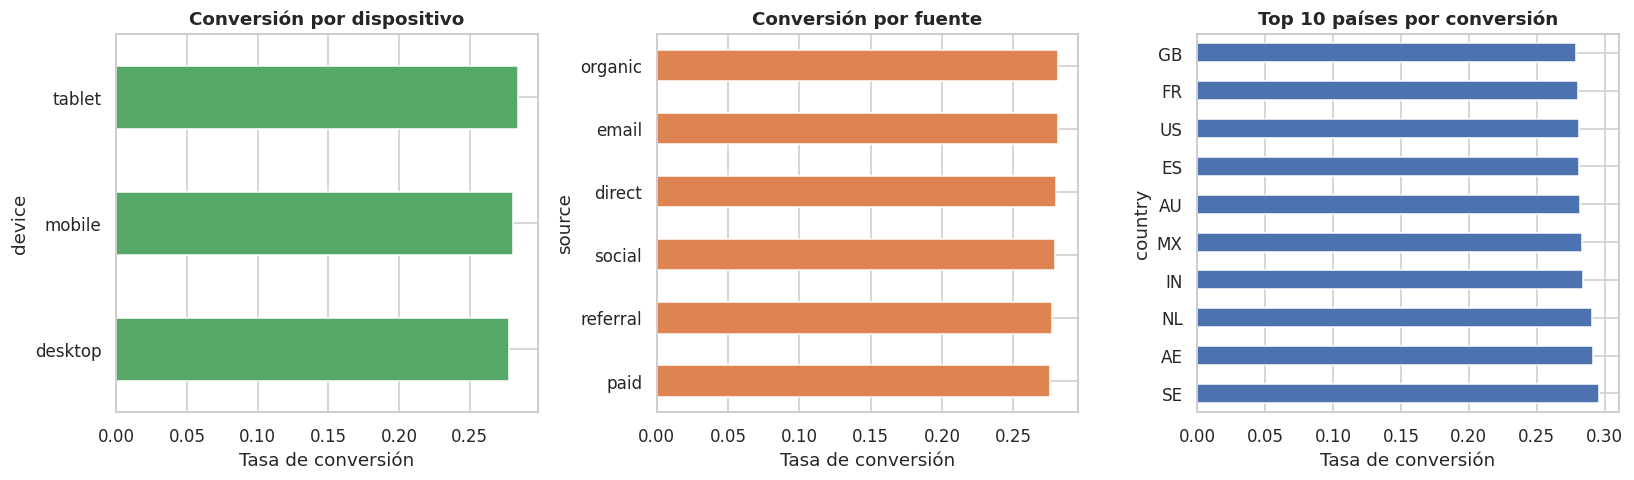

Rango de conversión por país: 25.7% – 29.6%


In [69]:
# Conversión por dispositivo, fuente y país
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sesiones.groupby("device")["compro"].mean().sort_values().plot(
    kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("Conversión por dispositivo")
axes[0].set_xlabel("Tasa de conversión")

sesiones.groupby("source")["compro"].mean().sort_values().plot(
    kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Conversión por fuente")
axes[1].set_xlabel("Tasa de conversión")

sesiones.groupby("country")["compro"].mean().sort_values(ascending=False).head(10).plot(
    kind="barh", ax=axes[2], color="#4C72B0")
axes[2].set_title("Top 10 países por conversión")
axes[2].set_xlabel("Tasa de conversión")

plt.tight_layout()
plt.show()

conversion_por_pais = sesiones.groupby("country")["compro"].mean().sort_values(ascending=False)
print(f"Rango de conversión por país: {conversion_por_pais.min()*100:.1f}% – {conversion_por_pais.max()*100:.1f}%")

**💡 Insight de negocio:** la conversión ronda el **28% sin importar dispositivo, fuente o país** — coincide con lo que ya había encontrado Carina para dispositivo y fuente en la sección 2.3.5, y el corte por país confirma el mismo patrón (rango de 25.7% a 29.6%, sin ningún país fuera de esa banda).

**💡 Conclusión:** dos análisis independientes (esta sección y la 2.3.5) llegan a la misma conclusión por caminos distintos, lo que da mayor confianza al hallazgo: **la conversión es uniforme entre segmentos**, y no hay una variable de canal o geografía que la explique en este dataset.

### 2.4.6 Precio y descuento vistos según resultado de la sesión

**Explicación técnica:** se calcula, por sesión, el precio promedio de los productos vistos (`page_view`) y el descuento promedio aplicado en caso de compra, y se comparan entre sesiones que terminaron en compra y las que no.

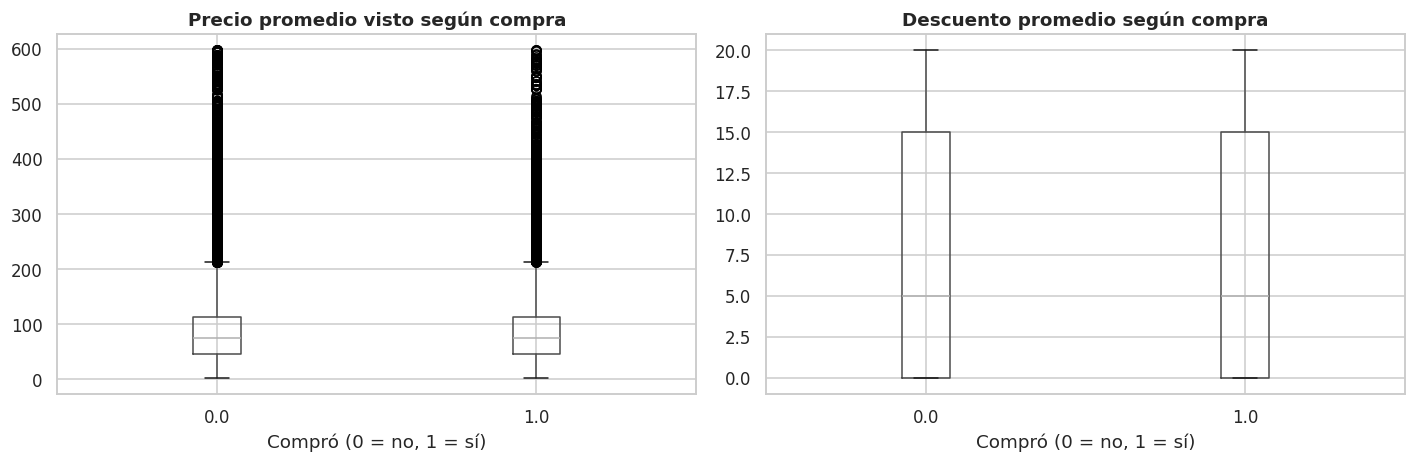

In [70]:
# Precio promedio visto por sesión (a partir de los page_view)
vistas_con_precio = (
    events[events["event_type"] == "page_view"]
    .merge(products[["product_id", "price_usd"]], on="product_id", how="left")
)
precio_promedio_visto = vistas_con_precio.groupby("session_id")["price_usd"].mean()
sesiones["precio_promedio_visto"] = sesiones["session_id"].map(precio_promedio_visto)

# Descuento promedio en las sesiones que sí compraron
descuento_promedio_sesion = (
    events[events["event_type"] == "purchase"]
    .groupby("session_id")["discount_pct"].mean()
)
sesiones["descuento_promedio"] = sesiones["session_id"].map(descuento_promedio_sesion)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sesiones.boxplot(column="precio_promedio_visto", by="compro", ax=axes[0])
axes[0].set_title("Precio promedio visto según compra")
axes[0].set_xlabel("Compró (0 = no, 1 = sí)")

sesiones.boxplot(column="descuento_promedio", by="compro", ax=axes[1])
axes[1].set_title("Descuento promedio según compra")
axes[1].set_xlabel("Compró (0 = no, 1 = sí)")

plt.suptitle("")
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** los boxplots no muestran una separación clara: el precio promedio visto y el descuento promedio son prácticamente iguales entre sesiones que terminaron en compra y las que no.

**💡 Conclusión:** en este dataset, ni el nivel de precio de lo que el usuario navega ni el descuento recibido tienen poder discriminante fuerte a nivel de sesión — consistente con la uniformidad de conversión ya observada en la sección anterior.

### 2.4.7 Matriz de correlación a nivel producto

**Explicación técnica:** se construye una tabla con una fila por producto, combinando información de las cinco tablas del proyecto: vistas y agregados al carrito (`events`), unidades vendidas, ingreso e descuento promedio (`order_items` + `orders`), edad promedio del comprador (`customers`), rating (`reviews`) y precio/margen (`products`). El objetivo es identificar qué variables se relacionan entre sí a nivel producto.

In [71]:
# --- Construcción de la tabla a nivel producto ---
vistas = events[events["event_type"] == "page_view"]
agregados_carrito = events[events["event_type"] == "add_to_cart"]

n_vistas = vistas.groupby("product_id").size()
n_vistas.index = n_vistas.index.astype(int)

n_agregados = agregados_carrito.groupby("product_id").size()
n_agregados.index = n_agregados.index.astype(int)

vistas_con_device = vistas.merge(sessions[["session_id", "device"]], on="session_id", how="left")
pct_vistas_mobile = (
    vistas_con_device.groupby("product_id")["device"]
    .value_counts(normalize=True).unstack(fill_value=0)
)
pct_vistas_mobile.index = pct_vistas_mobile.index.astype(int)
pct_vistas_mobile = pct_vistas_mobile.get("mobile", 0)

unidades_vendidas = order_items.groupby("product_id").size()
ingreso_promedio = order_items.groupby("product_id")["line_total_usd"].mean()

items_con_descuento = order_items[["order_id", "product_id"]].merge(
    orders[["order_id", "discount_pct"]].drop_duplicates("order_id"), on="order_id"
)
descuento_promedio_producto = items_con_descuento.groupby("product_id")["discount_pct"].mean()

edad_promedio_comprador = (
    order_items.merge(orders[["order_id", "customer_id"]], on="order_id")
    .merge(customers[["customer_id", "age"]], on="customer_id")
    .groupby("product_id")["age"].mean()
)

rating_promedio = reviews.groupby("product_id")["rating"].mean()
precio = products.set_index("product_id")["price_usd"]
margen = products.set_index("product_id")["margin_usd"]

tabla_producto = pd.DataFrame({
    "n_vistas": n_vistas,
    "n_agregados_carrito": n_agregados,
    "pct_vistas_mobile": pct_vistas_mobile,
    "unidades_vendidas": unidades_vendidas,
    "ingreso_promedio": ingreso_promedio,
    "descuento_promedio": descuento_promedio_producto,
    "edad_promedio_comprador": edad_promedio_comprador,
    "rating_promedio": rating_promedio,
    "precio": precio,
    "margen": margen,
}).dropna()

tabla_producto["tasa_carrito"] = (tabla_producto["n_agregados_carrito"] / tabla_producto["n_vistas"]).clip(upper=1)
tabla_producto["tasa_compra"] = (tabla_producto["unidades_vendidas"] / tabla_producto["n_vistas"]).clip(upper=1)

print(f"Productos incluidos en el análisis: {len(tabla_producto):,} de {len(products):,}")


Productos incluidos en el análisis: 1,140 de 1,197


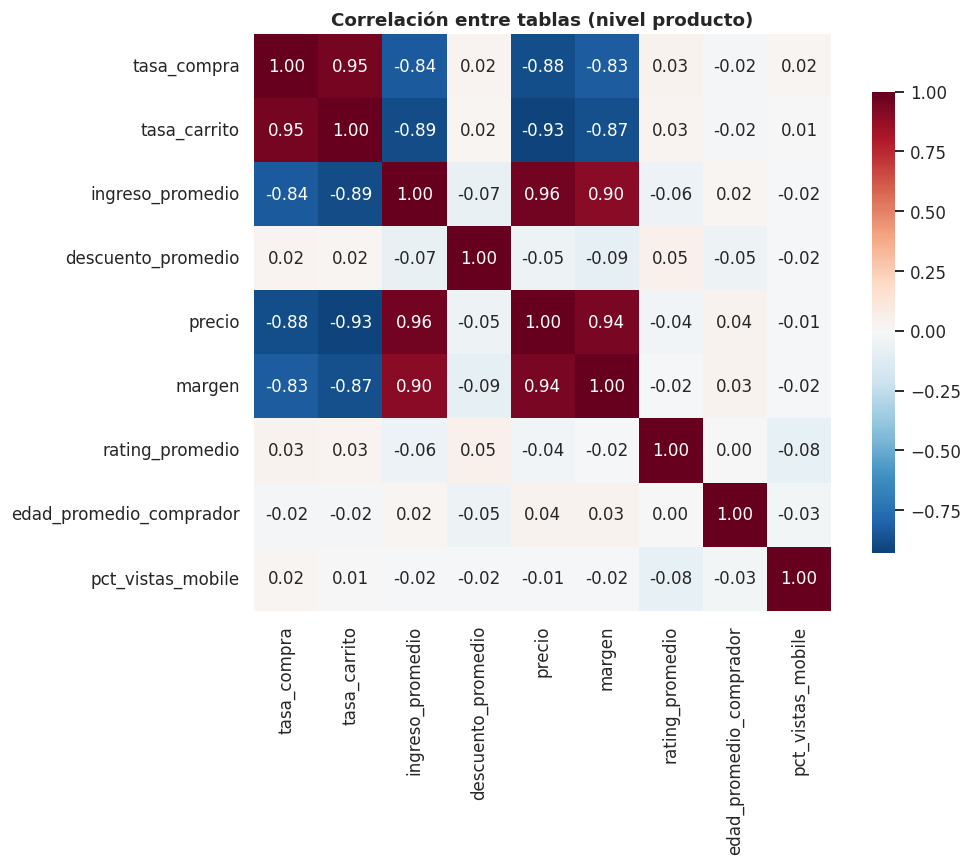

In [72]:
# --- Matriz de correlación ---
columnas_correlacion = [
    "tasa_compra", "tasa_carrito", "ingreso_promedio", "descuento_promedio",
    "precio", "margen", "rating_promedio", "edad_promedio_comprador", "pct_vistas_mobile",
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    tabla_producto[columnas_correlacion].corr(),
    annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True, cbar_kws={"shrink": 0.8},
)
plt.title("Correlación entre tablas (nivel producto)")
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** el precio es, por lejos, la variable con mayor poder explicativo a nivel producto: se relaciona fuerte y negativamente con la tasa de compra (r=-0.88) y la tasa de agregado al carrito (r=-0.93) — **los productos más baratos se venden proporcionalmente más** —, y fuerte y positivamente con el ingreso promedio por unidad (r=+0.96), lo cual es esperable (vender una unidad de un producto caro genera más ingreso que una unidad de uno barato). El resto de las variables (rating, descuento, edad del comprador, % de vistas desde mobile) tienen correlaciones cercanas a 0 con todo lo demás.

**💡 Conclusión:** para el sistema de recomendación, **`price_usd` es la variable de producto más informativa** para predecir popularidad o conversión — mucho más que el rating o el descuento. Esto es coherente con el hallazgo de la sección 2.2 (Elías): el catálogo tiene una brecha de precio marcada entre categorías, y esa brecha explica buena parte del comportamiento de compra a nivel producto.

### 2.4.8 Matriz usuario-producto: preparación para filtrado colaborativo

**Explicación técnica:** se construye la matriz de interacciones usuario-producto a partir de las compras (`order_items` + `orders`), y se cuantifican su tamaño, dispersión (*sparsity*) y los casos de *cold start* (productos con muy pocos compradores) — información necesaria para decidir qué técnica de recomendación es viable.


In [73]:
# Interacciones usuario-producto (a partir de las compras)
interacciones = order_items.merge(orders[["order_id", "customer_id"]], on="order_id")

n_usuarios = interacciones["customer_id"].nunique()
n_productos = interacciones["product_id"].nunique()
n_interacciones = len(interacciones)
pares_posibles = n_usuarios * n_productos
esparsidad = (1 - n_interacciones / pares_posibles) * 100

print("=== MATRIZ USUARIO-PRODUCTO (COMPRAS) ===")
print(f"Usuarios únicos:   {n_usuarios:>8,}")
print(f"Productos únicos:  {n_productos:>8,}")
print(f"Interacciones:     {n_interacciones:>8,}")
print(f"Pares posibles:    {pares_posibles:>12,}")
print(f"Esparsidad:        {esparsidad:.2f}%")

=== MATRIZ USUARIO-PRODUCTO (COMPRAS) ===
Usuarios únicos:     16,268
Productos únicos:     1,195
Interacciones:       59,163
Pares posibles:      19,440,260
Esparsidad:        99.70%


Productos con <5 compradores (cold start): 47 (3.9%)
Productos sin ninguna compra: 2 (0.2%)

Compras por usuario: media=3.62, mediana=3, máx=18
Compradores por producto: media=49.35, mediana=49, máx=138


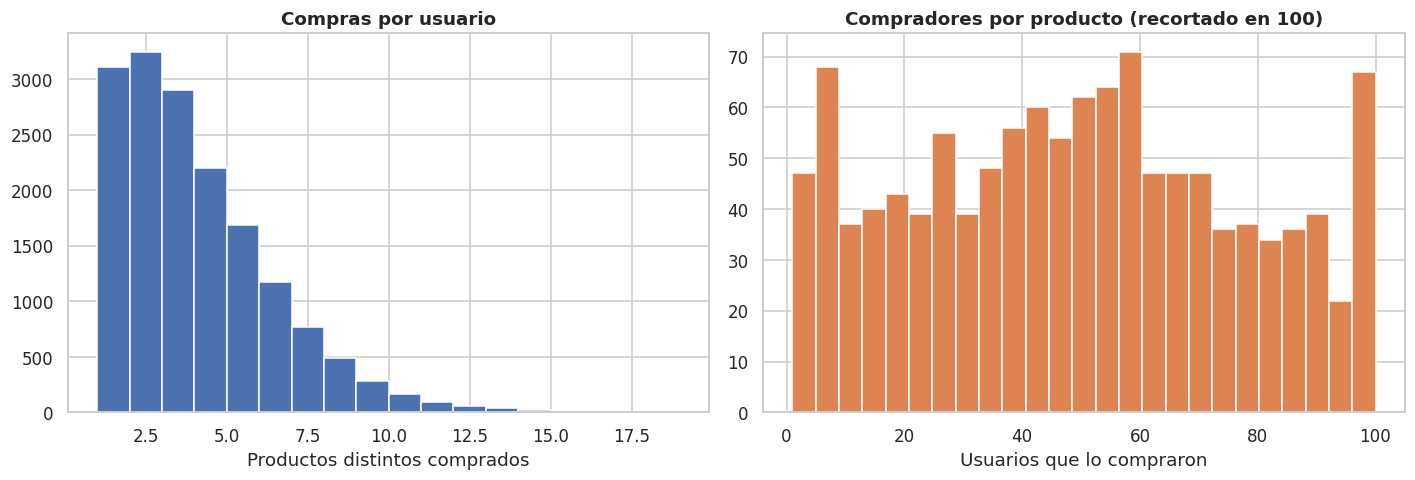

In [74]:
# Distribución de compras por usuario y por producto, y cold start
compras_por_usuario = interacciones.groupby("customer_id")["product_id"].nunique()
compradores_por_producto = interacciones.groupby("product_id")["customer_id"].nunique()

productos_cold_start = (compradores_por_producto < 5).sum()
productos_sin_compras = len(products) - n_productos

print(f"Productos con <5 compradores (cold start): {productos_cold_start} "
      f"({productos_cold_start/n_productos*100:.1f}%)")
print(f"Productos sin ninguna compra: {productos_sin_compras} "
      f"({productos_sin_compras/len(products)*100:.1f}%)")
print(f"\nCompras por usuario: media={compras_por_usuario.mean():.2f}, "
      f"mediana={compras_por_usuario.median():.0f}, máx={compras_por_usuario.max()}")
print(f"Compradores por producto: media={compradores_por_producto.mean():.2f}, "
      f"mediana={compradores_por_producto.median():.0f}, máx={compradores_por_producto.max()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(compras_por_usuario, bins=range(1, 20), color="#4C72B0", edgecolor="white")
axes[0].set_title("Compras por usuario")
axes[0].set_xlabel("Productos distintos comprados")

axes[1].hist(compradores_por_producto.clip(upper=100), bins=25, color="#DD8452", edgecolor="white")
axes[1].set_title("Compradores por producto (recortado en 100)")
axes[1].set_xlabel("Usuarios que lo compraron")

plt.tight_layout()
plt.show()


=== TOP 10 PRODUCTOS MÁS COMPRADOS ===
product_id
496     139
442     124
404     122
861     115
392     113
504     112
1148    112
769     111
366     111
265     111
dtype: int64

Productos con al menos 1 rating: 1140 de 1197

=== TOP 5 MEJOR VALORADOS (mínimo 5 ratings) ===
   product_id                         name        category      mean  count
0          53     Monitor LemonChiffon 452     Electronics  5.000000      6
1         814            Socks Magenta 735         Fashion  4.875000      8
2         761        Jacket DarkSalmon 406         Fashion  4.857143      7
3         221           Toaster Indigo 941  Home & Kitchen  4.857143      7
4         680  Tennis Racket PaleGreen 443          Sports  4.857143      7


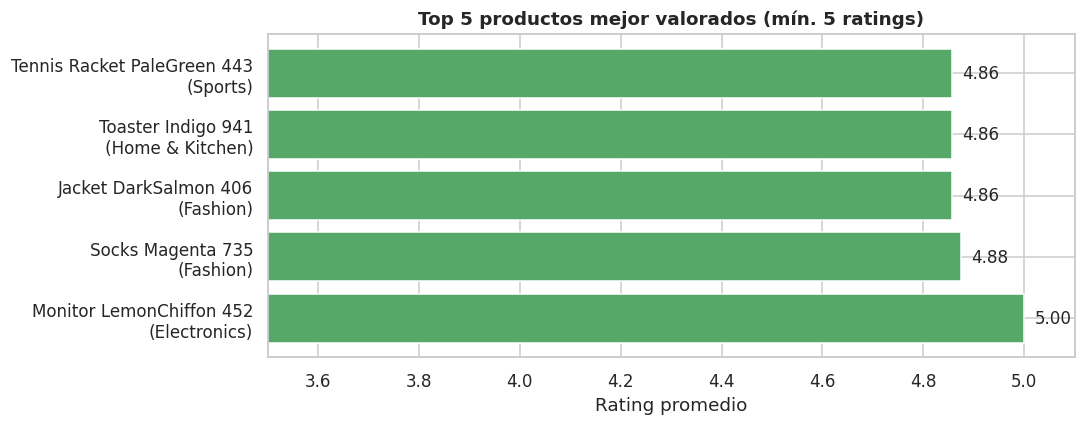

In [75]:
# Top 10 productos más comprados y productos mejor valorados (con al menos 5 ratings)
top10_mas_comprados = interacciones.groupby("product_id").size().sort_values(ascending=False).head(10)
print("=== TOP 10 PRODUCTOS MÁS COMPRADOS ===")
print(top10_mas_comprados)

rating_por_producto = reviews.groupby("product_id")["rating"].agg(["mean", "count"])
print(f"\nProductos con al menos 1 rating: {len(rating_por_producto)} de {len(products)}")

top5_mejor_valorados = (
    rating_por_producto[rating_por_producto["count"] >= 5]
    .sort_values("mean", ascending=False)
    .head(5)
    .reset_index()
    .merge(products[["product_id", "name", "category"]], on="product_id")
)
print("\n=== TOP 5 MEJOR VALORADOS (mínimo 5 ratings) ===")
print(top5_mejor_valorados[["product_id", "name", "category", "mean", "count"]])

fig, ax = plt.subplots(figsize=(10, 4))
etiquetas = [f"{fila['name'][:30]}\n({fila['category']})" for _, fila in top5_mejor_valorados.iterrows()]
barras = ax.barh(etiquetas, top5_mejor_valorados["mean"], color="#55A868")
ax.set_xlabel("Rating promedio")
ax.set_title("Top 5 productos mejor valorados (mín. 5 ratings)")
ax.set_xlim(3.5, 5.1)
for barra, valor in zip(barras, top5_mejor_valorados["mean"]):
    ax.text(barra.get_width() + 0.02, barra.get_y() + barra.get_height()/2, f"{valor:.2f}", va="center")
plt.tight_layout()
plt.show()


**💡 Insight de negocio:** la matriz usuario-producto tiene **16,268 usuarios × 1,195 productos**, con una esparsidad del **99.70%** — es decir, un usuario típico solo interactuó con una fracción mínima del catálogo. El **3.9% de los productos (47) tienen menos de 5 compradores** (cold start), y solo 2 productos del catálogo (0.2%) no se vendieron nunca — el mismo hallazgo que ya reportó Elías en la sección 2.2. Las compras por usuario son moderadas (media 3.6, mediana 3, máximo 18), sin usuarios que concentren un volumen desproporcionado.

**💡 Conclusión:** una esparsidad de 99.7% hace **inviables los métodos de vecinos cercanos densos**, pero sí es viable **factorización de matrices (SVD/ALS)**. El 3.9% de productos con cold start va a necesitar un enfoque basado en contenido (categoría, precio) en lugar de filtrado colaborativo puro, ya que no tienen suficiente historial de interacción.


### 📋 Informe Ejecutivo — "¿Qué opinan?"

**Resumen de hallazgos — Reviews y satisfacción**
1. Rating promedio de **3.93/5**, con 70.7% de reviews de 4 o 5 estrellas.
2. `review_text` no sirve para NLP: son 5 frases fijas, 1 a 1 con `rating`.
3. El rating **no se relaciona con precio (r=0.0005) ni varía significativamente por categoría** (rango 3.87–3.97).

**Resumen de hallazgos — Coherencia y calidad de datos**
4. Integridad referencial del 100% en las 6 relaciones verificadas; sincronía perfecta entre `purchase` events y `orders.csv` (33,580 = 33,580).
5. 4 reviews duplicadas exactas y 26 contradictorias.
6. **Hallazgo crítico:** ~51% de las reviews y ~50% de los pedidos violan la cadena causal de fechas (`signup_date ≤ order_time ≤ review_time`) — no se pueden construir features temporales hasta corregir esto en el origen.

**Resumen de hallazgos — Preparación para el sistema de recomendación**
7. Conversión uniforme (~28%) en todos los dispositivos, fuentes y países (confirma el hallazgo de Carina en 2.3.5, ahora también por país).
8. El precio es la variable de producto más predictiva (r=-0.88 con tasa de compra, r=-0.93 con tasa de carrito).
9. Matriz usuario-producto: 16,268 usuarios × 1,195 productos, esparsidad 99.7%, 3.9% de productos en cold start.

---

#### Limitaciones del dataset

El dataset es **100% sintético** (generado para fines educativos). Estas son limitaciones reales de los datos, no hallazgos de negocio:

| # | Limitación | Detalle | Impacto en el modelo |
|---|---|---|---|
| 1 | **Fechas aleatorias** | ~51% de las reviews son anteriores a su orden; ~50% de las órdenes son anteriores al signup del cliente. | No usar features temporales (recencia, antigüedad) ni split temporal train/test hasta corregir el origen de los datos. |
| 2 | **`review_text` fijo** | Solo 5 frases, cada una 1:1 con el rating. | No es posible aplicar NLP; usar solo `rating`. |
| 3 | **Reviews contradictorias** | 26 filas con distinto rating para el mismo (order_id, product_id). | Definir una regla de limpieza (quedarse con la más reciente o promediar). |

#### Recomendaciones de limpieza

| # | Acción | Justificación |
|---|---|---|
| 1 | Eliminar las 4 reviews duplicadas exactas | `drop_duplicates(subset=['order_id','product_id','rating'])`. |
| 2 | Resolver las 26 reviews contradictorias | Conservar la más reciente por `review_time`, o promediar el rating. |
| 3 | Corregir la coherencia temporal | Regenerar las columnas de fecha respetando `signup_date ≤ order_time ≤ review_time`. |
| 4 | No imputar los nulos estructurales de `events.csv` | Los NaN en `product_id`, `qty`, `cart_size` son estructurales — filtrar por `event_type` antes de usar cada columna. |
| 5 | Evaluar winsorizar `amount_usd` | Percentil 99 para reducir la influencia de pedidos atípicos sin descartarlos. |

#### Recomendaciones para Feature Engineering y Modelado

| Grupo | Features propuestas | Origen |
|---|---|---|
| Usuario | compras_totales, ticket_promedio, categoría_favorita | `orders` + `order_items` |
| Producto | popularidad (n_compradores), rating_promedio, margen_promedio | `order_items` + `reviews` + `products` |
| Sesión | eventos_por_sesión, tasa_de_abandono | `events` + `sessions` |

| Modelo | Qué hace | Cuándo usarlo |
|---|---|---|
| Baseline | Recomienda los productos más vendidos, igual para todos | Punto de comparación inicial |
| Content-Based | Recomienda por similitud de categoría, precio y margen | Cuando el producto tiene poco historial (cold start) |
| Collaborative Filtering (SVD/ALS) | Recomienda según usuarios similares | Cuando hay suficiente interacción usuario-producto |
| Híbrido | Combina CF + Content-Based | Para cubrir cold start sin perder personalización |

**Evaluación sugerida:** RMSE para predicción de ratings; Precision@K / Recall@K para calidad del ranking de recomendaciones.

---

## Conclusiones generales

Este EDA responde, con datos reales de las 7 tablas del proyecto, las cuatro preguntas de negocio del Sprint 1: quién compra, qué productos se venden, cómo compran y qué opinan.

**Sobre el cliente y su comportamiento (2.1, 2.3):** la base es demográficamente uniforme (sin sesgo por edad) y mobile-first, con una conversión global del 27.98% que se mantiene prácticamente constante entre dispositivos, fuentes de tráfico y países — la mayor fricción del proceso de compra está en el paso de carrito a checkout, no en el pago final, y ese patrón es estructural, no atribuible a un canal en particular.

**Sobre el catálogo (2.2):** el negocio vende de forma balanceada entre 7 categorías, con una brecha de precio marcada que concentra el margen en dólares en `Electronics`, mientras que el volumen de unidades está liderado por categorías más económicas (`Books`, `Toys`, `Beauty`).

**Sobre la satisfacción y la preparación para el modelo (2.4):** los usuarios califican bien en promedio (3.93/5) e independientemente del precio o la categoría del producto, y la matriz usuario-producto (esparsidad 99.7%) es viable para factorización de matrices, aunque un 3.9% de productos en cold start va a necesitar un enfoque basado en contenido.

**Limitación transversal más importante:** la cadena de fechas del dataset (`signup_date → order_time → review_time`) no es consistente en aproximadamente la mitad de los registros, lo que bloquea cualquier feature temporal (antigüedad, recencia) hasta que se corrija en el origen de los datos. Esta limitación fue detectada en la sección 2.4 pero aplica a todo el proyecto, incluida la Fase de Feature Engineering.

### Estado del Sprint 1

El EDA cubre íntegramente el alcance definido: perfilamiento de las 7 tablas, calidad de datos e integridad referencial verificadas, y las cuatro preguntas de negocio respondidas con evidencia cuantitativa. El notebook queda en condiciones de servir de base para `03_feature_engineering.ipynb`, con las limitaciones de datos ya documentadas para que no se trasladen sin control a las siguientes fases.
